<a href="https://colab.research.google.com/github/fayemauricepkp93-bot/conseils-malins-site/blob/main/generateur_collection_expert_energie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.7 MB/s eta 0:00:00


In [ ]:
# -*- coding: utf-8 -*-
"""
Générateur de manuel professionnel PDF
Cabinet Conseils Malins - NINEA : 005056413 JV4
Version 2.0 - Avec logo, QR code et corrections
"""

# ============================================================
# INSTALLATION DES DÉPENDANCES (décommenter si nécessaire)
# ============================================================
# !pip install reportlab qrcode[pil]

# ============================================================
# IMPORTS
# ============================================================
import os
import qrcode
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm, mm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY, TA_LEFT
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, PageBreak, NextPageTemplate, Image, HRFlowable
)
from reportlab.platypus.tableofcontents import TableOfContents

# ============================================================
# CONFIGURATION
# ============================================================
AUTEUR = "Maurice Faye"
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"
TITRE_DOC = "Expert Énergie – Manuel du Technicien"
SOUS_TITRE = "Diagnostic Électrique, Compteurs Woyofal & Efficacité Énergétique"
VERSION = "Édition 2026 – Version 1.0"

# Chemins et URL
LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = "Manuel_Expert_Energie_Cabinet_Conseils_Malins.pdf"

# Couleurs de marque
BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
GRIS_CLAIR = colors.HexColor("#F4F4F4")
GRIS_TEXTE = colors.HexColor("#333333")

# ============================================================
# GÉNÉRATION DU QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)
    print(f"✓ QR Code généré : {filename}")

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_titre_couv = ParagraphStyle(
    "TitreCouv", parent=styles["Title"],
    fontName="Helvetica-Bold", fontSize=28, leading=34,
    textColor=colors.white, alignment=TA_CENTER, spaceAfter=10
)
style_sous_titre_couv = ParagraphStyle(
    "SousTitreCouv", parent=styles["Normal"],
    fontName="Helvetica", fontSize=14, leading=18,
    textColor=colors.white, alignment=TA_CENTER
)
style_h1 = ParagraphStyle(
    "H1", parent=styles["Heading1"],
    fontName="Helvetica-Bold", fontSize=18, leading=22,
    textColor=BLEU_FONCE, spaceBefore=18, spaceAfter=10,
    borderPadding=6
)
style_h2 = ParagraphStyle(
    "H2", parent=styles["Heading2"],
    fontName="Helvetica-Bold", fontSize=14, leading=18,
    textColor=BLEU_MOYEN, spaceBefore=12, spaceAfter=6
)
style_h3 = ParagraphStyle(
    "H3", parent=styles["Heading3"],
    fontName="Helvetica-Bold", fontSize=12, leading=15,
    textColor=BLEU_MOYEN, spaceBefore=10, spaceAfter=4
)
style_corps = ParagraphStyle(
    "Corps", parent=styles["BodyText"],
    fontName="Helvetica", fontSize=10.5, leading=15,
    textColor=GRIS_TEXTE, alignment=TA_JUSTIFY, spaceAfter=6
)
style_encadre = ParagraphStyle(
    "Encadre", parent=style_corps,
    backColor=GRIS_CLAIR, borderColor=BLEU_CLAIR,
    borderWidth=1, borderPadding=8, spaceBefore=8, spaceAfter=10
)
style_exercice = ParagraphStyle(
    "Exercice", parent=style_corps,
    backColor=colors.HexColor("#FFF4E6"),
    borderColor=ORANGE, borderWidth=1, borderPadding=8,
    spaceBefore=8, spaceAfter=10
)
style_ref = ParagraphStyle(
    "Ref", parent=style_corps,
    fontSize=9.5, leading=13, leftIndent=12, firstLineIndent=-12,
    spaceAfter=4
)
style_qr_text = ParagraphStyle(
    "QRText", fontName="Helvetica", fontSize=9,
    textColor=colors.white, alignment=TA_CENTER
)

# ============================================================
# DOCUMENT TEMPLATE
# ============================================================
class ManuelDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)
        self.allowSplitting = 1

    def afterFlowable(self, flowable):
        if isinstance(flowable, Paragraph):
            style = flowable.style.name
            text = flowable.getPlainText()
            if style == "H1":
                self.notify("TOCEntry", (0, text, self.page))
            elif style == "H2":
                self.notify("TOCEntry", (1, text, self.page))

def page_couverture(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, 0, A4[0], A4[1], fill=1, stroke=0)
    canvas.setFillColor(ORANGE)
    canvas.rect(0, A4[1] - 2*cm, A4[0], 2*cm, fill=1, stroke=0)
    canvas.restoreState()

def page_standard(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, A4[1] - 1.6*cm, A4[0], 1.6*cm, fill=1, stroke=0)
    canvas.setFillColor(colors.white)
    canvas.setFont("Helvetica-Bold", 9)
    canvas.drawString(2*cm, A4[1] - 1.0*cm, ORGANISATION)
    canvas.setFont("Helvetica", 8)
    canvas.drawRightString(A4[0] - 2*cm, A4[1] - 1.0*cm, TITRE_DOC)
    canvas.setStrokeColor(BLEU_CLAIR)
    canvas.setLineWidth(0.5)
    canvas.line(2*cm, 1.5*cm, A4[0] - 2*cm, 1.5*cm)
    canvas.setFillColor(BLEU_FONCE)
    canvas.setFont("Helvetica", 8)
    canvas.drawString(2*cm, 1.0*cm, f"NINEA : {NINEA}  |  {WHATSAPP}")
    canvas.drawRightString(A4[0] - 2*cm, 1.0*cm, f"Page {doc.page}")
    canvas.restoreState()

# ============================================================
# CONSTRUCTION DU CONTENU
# ============================================================
def build_content():
    story = []

    # ---------- COUVERTURE ----------
    story.append(Spacer(1, 1*cm))
    if os.path.exists(LOGO_PATH):
        story.append(Image(LOGO_PATH, width=4*cm, height=4*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("EXPERT ÉNERGIE", ParagraphStyle(
        "Marque", fontName="Helvetica-Bold", fontSize=16,
        textColor=ORANGE, alignment=TA_CENTER, spaceAfter=20)))
    story.append(Paragraph(TITRE_DOC, style_titre_couv))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(SOUS_TITRE, style_sous_titre_couv))
    story.append(Spacer(1, 2*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b><br/>{LIEU}<br/>NINEA : {NINEA}",
        ParagraphStyle("InfosCouv", fontName="Helvetica", fontSize=11,
                       textColor=colors.white, alignment=TA_CENTER, leading=16)))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(VERSION, ParagraphStyle(
        "Version", fontName="Helvetica-Oblique", fontSize=10,
        textColor=colors.white, alignment=TA_CENTER)))
    story.append(Spacer(1, 1.5*cm))
    if os.path.exists(QR_PATH):
        story.append(Image(QR_PATH, width=3*cm, height=3*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.2*cm))
        story.append(Paragraph("Scannez pour nous contacter sur WhatsApp", style_qr_text))
    story.append(NextPageTemplate("standard"))
    story.append(PageBreak())

    # ---------- PAGE DE CRÉDITS ----------
    story.append(Paragraph("À propos de ce manuel", style_h1))
    story.append(Paragraph(
        "Ce manuel constitue le support pédagogique officiel de la Masterclass "
        "Expert Énergie dispensée par le Cabinet Conseils Malins. Il couvre "
        "l'intégralité de la chaîne électrique résidentielle et tertiaire, de "
        "la sécurité des installations jusqu'aux audits énergétiques avancés, "
        "en passant par la maîtrise des compteurs prépayés Senelec Woyofal.", style_corps))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("Auteur", style_h2))
    story.append(Paragraph(
        f"<b>{AUTEUR}</b> – Expert-Conseil en électrotechnique, "
        f"diagnostic résidentiel et efficacité énergétique.", style_corps))
    story.append(Paragraph("Contact & Informations légales", style_h2))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b><br/>"
        f"NINEA : {NINEA}<br/>"
        f"WhatsApp : {WHATSAPP}<br/>"
        f"Email : {EMAIL}<br/>"
        f"Lieu : {LIEU}", style_corps))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(
        "<b>Droits d'auteur :</b> © 2026 Cabinet Conseils Malins. Tous droits réservés. "
        "Reproduction, diffusion ou revente interdites sans autorisation écrite. "
        "Usage personnel ou entreprise acheteuse uniquement.", style_encadre))
    story.append(PageBreak())

    # ---------- TABLE DES MATIÈRES ----------
    story.append(Paragraph("Table des matières", style_h1))
    toc = TableOfContents()
    toc.levelStyles = [
        ParagraphStyle("TOC1", fontName="Helvetica-Bold", fontSize=11,
                       textColor=BLEU_FONCE, spaceBefore=8, spaceAfter=2),
        ParagraphStyle("TOC2", fontName="Helvetica", fontSize=10,
                       textColor=GRIS_TEXTE, leftIndent=18, spaceAfter=1),
    ]
    story.append(toc)
    story.append(PageBreak())

    # ========================================================
    # MODULE 1
    # ========================================================
    story.append(Paragraph("Module 1 – Sécurité et diagnostic des risques électriques", style_h1))
    story.append(Paragraph(
        "Le courant électrique présente des risques majeurs pour le corps humain. "
        "Ce module pose les bases physiologiques et normatives indispensables à "
        "toute intervention sur une installation.", style_corps))

    story.append(Paragraph("1.1 Seuils physiologiques du courant alternatif (50/60 Hz)", style_h2))
    data = [
        ["Seuil", "Intensité", "Effet sur le corps"],
        ["Perception", "~0,5 mA", "Légers picotements"],
        ["Non-lâchage", "~10 mA", "Contraction musculaire tétanisante"],
        ["Fibrillation ventriculaire", ">30 à 50 mA", "Danger mortel (>1 seconde)"],
    ]
    t = Table(data, colWidths=[4*cm, 3.5*cm, 8*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 10),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("LEFTPADDING", (0, 0), (-1, -1), 6),
        ("RIGHTPADDING", (0, 0), (-1, -1), 6),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.4*cm))
    story.append(Paragraph(
        "<b>À retenir :</b> En milieu sec, la tension de contact admissible ne doit "
        "pas dépasser <b>50 V</b> en régime permanent. La résistance du corps humain "
        "varie selon l'état de la peau (sèche, humide, immergée).", style_encadre))

    story.append(Paragraph("1.2 Régimes de neutre (Schémas de Liaison à la Terre)", style_h2))
    data = [
        ["Régime", "Principe", "Premier défaut", "Second défaut"],
        ["TN", "Neutre relié à la terre ; masses au PE",
         "Court-circuit phase-masse → déclenchement immédiat",
         "Coupure par surintensité"],
        ["TT", "Neutre et masses à des terres séparées",
         "Tension dangereuse sur les masses → DDR obligatoire",
         "Risque accru si DDR défectueux"],
        ["IT", "Neutre isolé ou impédant",
         "Courant capacitif faible → signalisation",
         "Coupure obligatoire au 2e défaut"],
    ]
    t = Table(data, colWidths=[1.8*cm, 4*cm, 5.2*cm, 4.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("LEFTPADDING", (0, 0), (-1, -1), 5),
        ("RIGHTPADDING", (0, 0), (-1, -1), 5),
        ("TOPPADDING", (0, 0), (-1, -1), 4),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 4),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
    ]))
    story.append(t)

    story.append(Paragraph("1.3 Méthodologie de diagnostic et appareils de mesure", style_h2))
    for item in [
        "<b>Multimètre</b> : tension phase-neutre (230 V ±10 %), tension neutre-terre (<2 V).",
        "<b>Pince ampèremétrique TRMS</b> : courant de fuite global (<15 mA ; risque si >30 mA).",
        "<b>Mégohmmètre 500 V DC</b> : résistance d'isolement ≥0,5 MΩ.",
        "<b>Telluromètre</b> : prise de terre ≤30 Ω (norme locale).",
    ]:
        story.append(Paragraph(f"• {item}", style_corps))

    story.append(Paragraph("Exercice 1 – Régime TT", style_h3))
    story.append(Paragraph(
        "Installation 230 V, prise de terre R = 40 Ω, DDR 30 mA.<br/>"
        "<b>Q1 :</b> Calculer le courant de défaut.<br/>"
        "<b>Q2 :</b> Le DDR déclenche-t-il ?", style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> I_d = 230/40 = 5,75 A = 5750 mA ≫ 30 mA → déclenchement instantané.",
        style_corps))
    story.append(PageBreak())

    # ========================================================
    # MODULE 2
    # ========================================================
    story.append(Paragraph("Module 2 – Architecture et dimensionnement des protections", style_h1))
    story.append(Paragraph(
        "Le dimensionnement correct des protections garantit la sécurité des "
        "personnes et la durabilité des équipements. Ce module aborde la chute "
        "de tension, la sélectivité et les parafoudres.", style_corps))

    story.append(Paragraph("2.1 Chute de tension", style_h2))
    story.append(Paragraph(
        "Formule monophasée : <b>ΔU = 2 × L × I × (r·cos φ + x·sin φ) / S</b><br/>"
        "Limites normatives : ≤3 % éclairage, ≤5 % force motrice.", style_corps))

    story.append(Paragraph("2.2 Sélectivité des protections", style_h2))
    story.append(Paragraph(
        "• <b>Ampèremétrique</b> : rapport des calibres amont/aval ≥1,6.<br/>"
        "• <b>Chronométrique</b> : temporisation des protections amont.", style_corps))

    story.append(Paragraph("2.3 Parafoudres (SPD)", style_h2))
    data = [
        ["Type", "Zone d'installation", "Onde d'impulsion"],
        ["Type 1", "Origine (paratonnerre)", "10/350 µs"],
        ["Type 2", "Tableau divisionnaire", "8/20 µs"],
        ["Type 3", "Proximité équipements", "Ondes combinées"],
    ]
    t = Table(data, colWidths=[2.5*cm, 8*cm, 5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 10),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)

    story.append(Paragraph("Exercice 2 – Chute de tension", style_h3))
    story.append(Paragraph(
        "Câble cuivre L=45 m, I=26 A, cos φ=0,85, S=6 mm², r=0,023 Ω·mm²/m.<br/>"
        "<b>Q1 :</b> Calculer ΔU.<br/>"
        "<b>Q2 :</b> Conclusion NFC 15-100.", style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> ΔU = (2×45×26×0,023×0,85)/6 ≈ 8,13 V → 3,53 %. "
        "Conforme force motrice (<5 %), mais nécessite 10 mm² pour éclairage.", style_corps))
    story.append(PageBreak())

    # ========================================================
    # MODULE 3
    # ========================================================
    story.append(Paragraph("Module 3 – Audit énergétique et chasse aux pertes", style_h1))
    story.append(Paragraph("3.1 Méthodologie en 4 étapes", style_h2))
    for item in [
        "Collecte des factures sur 12 mois.",
        "Inspection visuelle et inventaire des équipements.",
        "Mesures physiques (pinces wattmétriques, isolement, terre).",
        "Rapport de préconisations avec ROI.",
    ]:
        story.append(Paragraph(f"• {item}", style_corps))

    story.append(Paragraph("3.2 Facteur de puissance et compensation", style_h2))
    story.append(Paragraph(
        "<b>Q_c = P × [tan(φ₁) − tan(φ₂)]</b><br/>"
        "Objectif : cos φ > 0,90 pour éliminer les pénalités Senelec.", style_corps))

    story.append(Paragraph("3.3 Audit climatisation et froid", style_h2))
    story.append(Paragraph(
        "• <b>Clim</b> : consigne recommandée 24–25 °C (économie 20–30 %).<br/>"
        "• <b>Froid</b> : test de la feuille sur joint de porte. Nettoyage condenseur "
        "(économie 20 %). Thermostat niveau moyen.", style_corps))

    story.append(Paragraph("3.4 Calcul d'impact financier d'une fuite", style_h2))
    story.append(Paragraph(
        "Fuite 100 mA sous 230 V :<br/>"
        "P = 23 W → 0,552 kWh/jour → 16,56 kWh/mois → <b>~2 250 FCFA/mois</b> "
        "(tranche 2 à 136 FCFA/kWh).", style_encadre))

    story.append(Paragraph("Exercice 3 – Compensation d'énergie réactive", style_h3))
    story.append(Paragraph(
        "P = 35 kW, cos φ₁ = 0,70 (tan=1,02), cos φ₂ = 0,95 (tan=0,33).<br/>"
        "<b>Q1 :</b> Calculer Qc.<br/>"
        "<b>Q2 :</b> Code Woyofal pour puissance instantanée.", style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> Qc = 35×(1,02−0,33) = 24,15 kVAR. Code 814.", style_corps))
    story.append(PageBreak())

    # ========================================================
    # MODULE 4
    # ========================================================
    story.append(Paragraph("Module 4 – Maîtrise avancée des compteurs Woyofal", style_h1))
    story.append(Paragraph("4.1 Fonctionnement STS", style_h2))
    story.append(Paragraph(
        "Norme internationale STS. Jeton numérique de 20 chiffres. "
        "Relais interne coupe à 0 kWh.", style_corps))

    story.append(Paragraph("4.2 Codes Woyofal harmonisés", style_h2))
    data = [
        ["Code", "Paramètre", "Utilité pratique"],
        ["808", "Courant instantané (A)", "Détection fuite : couper tous récepteurs, si >0 A → fuite"],
        ["809", "Type de compteur / profil tarifaire", "Vérifier l'abonnement"],
        ["813", "Tension réseau (V)", "Sous-tension <190 V → surchauffe moteurs"],
        ["814", "Puissance instantanée (W)", "Mesure en temps réel"],
        ["870", "État du relais interne", "Armé / déclenché"],
        ["820", "Consommation du mois (kWh)", "Évaluer tranche sociale (150 kWh)"],
    ]
    t = Table(data, colWidths=[1.8*cm, 5*cm, 8.7*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        "<i>Note : certains codes varient selon la marque (Hexing, Inhemeter, Sanxing). "
        "Se référer à la notice constructeur.</i>", style_corps))

    story.append(Paragraph("4.3 Anomalies de câblage", style_h2))
    data = [
        ["Anomalie", "Origine", "Risque", "Impact Woyofal"],
        ["Défaut de terre", "Défaut d'isolement", "Électrocution", "Surconsommation continue"],
        ["Défaut de neutre", "Neutre desserré/coupé/croisé", "Surtension destructive", "Erreurs de mesure"],
        ["Inversion phase/neutre", "Erreur de câblage",
         "Interrupteurs coupent le neutre (appareil sous tension)",
         "Perturbation du diagnostic de fuite"],
    ]
    t = Table(data, colWidths=[3*cm, 4*cm, 5*cm, 4.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)
    story.append(PageBreak())

    # ========================================================
    # MODULE 5
    # ========================================================
    story.append(Paragraph("Module 5 – Études de cas et restitution professionnelle", style_h1))
    story.append(Paragraph("5.1 Protocole d'intervention en 5 phases", style_h2))
    for item in [
        "Entretien préliminaire.",
        "Inspection visuelle + code 808 à vide.",
        "Tests différentiels et isolement.",
        "Audit des appareils.",
        "Rédaction du rapport.",
    ]:
        story.append(Paragraph(f"• {item}", style_corps))

    story.append(Paragraph("5.2 Structure du rapport d'audit", style_h2))
    data = [
        ["Section", "Contenu"],
        ["1. État des lieux", "Identité, n° compteur, terre, tableau"],
        ["2. Anomalies relevées", "Inversion, absence DDR, fuite, clim sous-dimensionnée"],
        ["3. Plan d'action", "Urgent, priorité élevée, conseils"],
        ["4. Devis", "Main-d'œuvre + fournitures"],
    ]
    t = Table(data, colWidths=[4.5*cm, 11*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 10),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)

    story.append(Paragraph("5.3 Cas pratique – Villa R+1 à Thiès", style_h2))
    story.append(Paragraph(
        "<b>Symptômes :</b> déclenchements DDR, crédit épuisé (450 kWh/mois pour 2 occupants).<br/>"
        "<b>Investigations :</b> défaut isolement chauffe-eau (1,2 kΩ), clim inverter défectueuse "
        "(compresseur 100 %).<br/>"
        "<b>Actions :</b> remplacement thermostat, réparation liaison équipotentielle, sonde clim, "
        "consigne 24 °C.<br/>"
        "<b>Résultat :</b> –40 % de consommation mensuelle.", style_corps))

    story.append(Paragraph("5.4 Label Karangué-Elec", style_h2))
    story.append(Paragraph(
        "Garantit conformité NFC 15-100, sécurité des biens et personnes, "
        "optimisation durable.", style_corps))
    story.append(PageBreak())

    # ========================================================
    # RÉFÉRENCES & SOURCES
    # ========================================================
    story.append(Paragraph("Références & Sources", style_h1))
    story.append(Paragraph(
        "Ce manuel s'appuie sur les normes internationales, les documentations "
        "constructeurs et les retours d'expérience terrain du Cabinet Conseils Malins.",
        style_corps))

    story.append(Paragraph("Normes et référentiels techniques", style_h2))
    for r in [
        "NF C 15-100 – Installations électriques à basse tension (AFNOR).",
        "Standard Transfer Specification (STS) – Norme internationale pour compteurs prépayés.",
        "Senelec – Documentation technique et tarification progressive Woyofal.",
        "IEC 60364 – Electrical installations of buildings (Commission Électrotechnique Internationale).",
    ]:
        story.append(Paragraph(f"• {r}", style_ref))

    story.append(Paragraph("Documentations constructeurs", style_h2))
    for r in [
        "ENGELEC Group – Three Phase Keypad Token Prepaid Electricity Meter (www.engelegroup.com).",
        "ZHENGXI Electric Group – Single Phase Automatic Voltage Regulator TND5-15KVA "
        "(zjzhengxi.en.made-in-china.com).",
        "Hexing – Compteurs prépayés STS.",
        "Inhemeter – Compteurs prépayés STS.",
        "Sanxing – Compteurs prépayés STS.",
        "Fluke – Appareils de mesure électrique (multimètres, pinces, mégohmmètres).",
    ]:
        story.append(Paragraph(f"• {r}", style_ref))

    story.append(Paragraph("Sources documentaires et iconographiques", style_h2))
    for r in [
        "Cabinet Conseils Malins – Support de cours Masterclass Woyofal (édition 2026).",
        "Cabinet Conseils Malins – Recueil complet des 5 modules de formation.",
        "Cabinet Conseils Malins – Exercices pratiques et corrigés.",
        "Cabinet Conseils Malins – Schémas de câblage solaire hybride.",
        "Banque d'images Google Veo 3.1 – Illustrations pédagogiques (gadgets360.com).",
        "The Pinnacle St. – Photographie professionnelle d'inspection électrique "
        "(www.thepinnaclest.com).",
        "Ressources visuelles Facebook – Démonstrations froid et mesures électriques.",
    ]:
        story.append(Paragraph(f"• {r}", style_ref))

    story.append(Paragraph("Remerciements", style_h2))
    story.append(Paragraph(
        "Nous remercions l'ensemble des techniciens, stagiaires et clients du "
        "Cabinet Conseils Malins dont les retours d'expérience ont enrichi ce manuel. "
        "Une mention particulière à nos partenaires installateurs et aux formateurs "
        "qui contribuent chaque jour à la diffusion des bonnes pratiques énergétiques "
        "au Sénégal.", style_corps))

    story.append(Spacer(1, 1*cm))
    story.append(HRFlowable(width="100%", thickness=1, color=BLEU_CLAIR))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b> – NINEA : {NINEA}<br/>"
        f"WhatsApp : {WHATSAPP} – Email : {EMAIL}<br/>"
        f"© 2026 – Tous droits réservés.",
        ParagraphStyle("Footer", parent=style_corps, alignment=TA_CENTER, fontSize=9)))

    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_pdf(nom_fichier=NOM_FICHIER):
    doc = ManuelDoc(
        nom_fichier,
        pagesize=A4,
        leftMargin=2*cm, rightMargin=2*cm,
        topMargin=2.2*cm, bottomMargin=2*cm,
        title=TITRE_DOC,
        author=AUTEUR,
        subject=SOUS_TITRE,
        creator=ORGANISATION,
    )
    frame_couv = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4*cm, id="couv")
    frame_std = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4.2*cm, id="std")
    doc.addPageTemplates([
        PageTemplate(id="couverture", frames=[frame_couv], onPage=page_couverture),
        PageTemplate(id="standard", frames=[frame_std], onPage=page_standard),
    ])
    story = build_content()
    doc.multiBuild(story)
    print(f"✓ PDF généré : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
# 1. Générer le QR Code
generate_qr(QR_URL, QR_PATH)

# 2. Générer le PDF
generer_pdf()

# 3. Télécharger automatiquement le PDF (dans Colab)
try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le PDF est enregistré localement.")

✓ QR Code généré : qr_code.png
✓ PDF généré : /content/Manuel_Expert_Energie_Cabinet_Conseils_Malins.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


In [ ]:
# -*- coding: utf-8 -*-
"""
Tome 2 - Efficacité Énergétique Avancée
Solaire, Domotique, Régulation & Gestion PME
Cabinet Conseils Malins - NINEA : 005056413 JV4
"""

import os
import qrcode
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, PageBreak, NextPageTemplate, Image, HRFlowable
)
from reportlab.platypus.tableofcontents import TableOfContents

# ============================================================
# CONFIGURATION
# ============================================================
AUTEUR = "Maurice Faye"
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"
TITRE_DOC = "Expert Énergie – Tome 2 : Solutions Avancées"
SOUS_TITRE = "Solaire Hybride, Domotique, Régulation & Gestion Énergétique PME"
VERSION = "Édition 2026 – Version 1.0"

LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = "Tome-2_Solaire-Domotique-PME_Cabinet-Conseils-Malins.pdf"

BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
GRIS_CLAIR = colors.HexColor("#F4F4F4")
GRIS_TEXTE = colors.HexColor("#333333")

# ============================================================
# QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)
    print(f"✓ QR Code généré : {filename}")

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_titre_couv = ParagraphStyle("TitreCouv", parent=styles["Title"],
    fontName="Helvetica-Bold", fontSize=26, leading=32,
    textColor=colors.white, alignment=TA_CENTER, spaceAfter=10)
style_sous_titre_couv = ParagraphStyle("SousTitreCouv", parent=styles["Normal"],
    fontName="Helvetica", fontSize=13, leading=17,
    textColor=colors.white, alignment=TA_CENTER)
style_h1 = ParagraphStyle("H1", parent=styles["Heading1"],
    fontName="Helvetica-Bold", fontSize=18, leading=22,
    textColor=BLEU_FONCE, spaceBefore=18, spaceAfter=10, borderPadding=6)
style_h2 = ParagraphStyle("H2", parent=styles["Heading2"],
    fontName="Helvetica-Bold", fontSize=14, leading=18,
    textColor=BLEU_MOYEN, spaceBefore=12, spaceAfter=6)
style_h3 = ParagraphStyle("H3", parent=styles["Heading3"],
    fontName="Helvetica-Bold", fontSize=12, leading=15,
    textColor=BLEU_MOYEN, spaceBefore=10, spaceAfter=4)
style_corps = ParagraphStyle("Corps", parent=styles["BodyText"],
    fontName="Helvetica", fontSize=10.5, leading=15,
    textColor=GRIS_TEXTE, alignment=TA_JUSTIFY, spaceAfter=6)
style_encadre = ParagraphStyle("Encadre", parent=style_corps,
    backColor=GRIS_CLAIR, borderColor=BLEU_CLAIR,
    borderWidth=1, borderPadding=8, spaceBefore=8, spaceAfter=10)
style_exercice = ParagraphStyle("Exercice", parent=style_corps,
    backColor=colors.HexColor("#FFF4E6"), borderColor=ORANGE,
    borderWidth=1, borderPadding=8, spaceBefore=8, spaceAfter=10)
style_ref = ParagraphStyle("Ref", parent=style_corps,
    fontSize=9.5, leading=13, leftIndent=12, firstLineIndent=-12, spaceAfter=4)
style_qr_text = ParagraphStyle("QRText", fontName="Helvetica", fontSize=9,
    textColor=colors.white, alignment=TA_CENTER)

# ============================================================
# DOCUMENT TEMPLATE
# ============================================================
class ManuelDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)
        self.allowSplitting = 1
    def afterFlowable(self, flowable):
        if isinstance(flowable, Paragraph):
            style = flowable.style.name
            text = flowable.getPlainText()
            if style == "H1":
                self.notify("TOCEntry", (0, text, self.page))
            elif style == "H2":
                self.notify("TOCEntry", (1, text, self.page))

def page_couverture(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, 0, A4[0], A4[1], fill=1, stroke=0)
    canvas.setFillColor(ORANGE)
    canvas.rect(0, A4[1] - 2*cm, A4[0], 2*cm, fill=1, stroke=0)
    canvas.restoreState()

def page_standard(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, A4[1] - 1.6*cm, A4[0], 1.6*cm, fill=1, stroke=0)
    canvas.setFillColor(colors.white)
    canvas.setFont("Helvetica-Bold", 9)
    canvas.drawString(2*cm, A4[1] - 1.0*cm, ORGANISATION)
    canvas.setFont("Helvetica", 8)
    canvas.drawRightString(A4[0] - 2*cm, A4[1] - 1.0*cm, "Expert Énergie – Tome 2")
    canvas.setStrokeColor(BLEU_CLAIR)
    canvas.setLineWidth(0.5)
    canvas.line(2*cm, 1.5*cm, A4[0] - 2*cm, 1.5*cm)
    canvas.setFillColor(BLEU_FONCE)
    canvas.setFont("Helvetica", 8)
    canvas.drawString(2*cm, 1.0*cm, f"NINEA : {NINEA}  |  {WHATSAPP}")
    canvas.drawRightString(A4[0] - 2*cm, 1.0*cm, f"Page {doc.page}")
    canvas.restoreState()

# ============================================================
# CONTENU
# ============================================================
def build_content():
    story = []

    # ---------- COUVERTURE ----------
    story.append(Spacer(1, 1*cm))
    if os.path.exists(LOGO_PATH):
        story.append(Image(LOGO_PATH, width=4*cm, height=4*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("EXPERT ÉNERGIE – TOME 2", ParagraphStyle(
        "Marque", fontName="Helvetica-Bold", fontSize=15,
        textColor=ORANGE, alignment=TA_CENTER, spaceAfter=20)))
    story.append(Paragraph(TITRE_DOC, style_titre_couv))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(SOUS_TITRE, style_sous_titre_couv))
    story.append(Spacer(1, 2*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b><br/>{LIEU}<br/>NINEA : {NINEA}",
        ParagraphStyle("InfosCouv", fontName="Helvetica", fontSize=11,
                       textColor=colors.white, alignment=TA_CENTER, leading=16)))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(VERSION, ParagraphStyle(
        "Version", fontName="Helvetica-Oblique", fontSize=10,
        textColor=colors.white, alignment=TA_CENTER)))
    story.append(Spacer(1, 1.5*cm))
    if os.path.exists(QR_PATH):
        story.append(Image(QR_PATH, width=3*cm, height=3*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.2*cm))
        story.append(Paragraph("Scannez pour nous contacter sur WhatsApp", style_qr_text))
    story.append(NextPageTemplate("standard"))
    story.append(PageBreak())

    # ---------- CRÉDITS ----------
    story.append(Paragraph("À propos de ce manuel", style_h1))
    story.append(Paragraph(
        "Ce second tome de la collection Expert Énergie s'adresse aux techniciens "
        "supérieurs, ingénieurs, installateurs solaires et chefs d'entreprise. "
        "Il couvre les solutions avancées d'efficacité énergétique : installations "
        "solaires hybrides, domotique, régulation de tension et gestion électrique "
        "en milieu professionnel.", style_corps))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("Auteur", style_h2))
    story.append(Paragraph(
        f"<b>{AUTEUR}</b> – Expert-Conseil en électrotechnique, "
        f"diagnostic résidentiel et efficacité énergétique.", style_corps))
    story.append(Paragraph("Contact & Informations légales", style_h2))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b><br/>NINEA : {NINEA}<br/>"
        f"WhatsApp : {WHATSAPP}<br/>Email : {EMAIL}<br/>Lieu : {LIEU}", style_corps))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(
        "<b>Droits d'auteur :</b> © 2026 Cabinet Conseils Malins. Tous droits réservés. "
        "Reproduction, diffusion ou revente interdites sans autorisation écrite. "
        "Usage personnel ou entreprise acheteuse uniquement.", style_encadre))
    story.append(PageBreak())

    # ---------- TABLE DES MATIÈRES ----------
    story.append(Paragraph("Table des matières", style_h1))
    toc = TableOfContents()
    toc.levelStyles = [
        ParagraphStyle("TOC1", fontName="Helvetica-Bold", fontSize=11,
                       textColor=BLEU_FONCE, spaceBefore=8, spaceAfter=2),
        ParagraphStyle("TOC2", fontName="Helvetica", fontSize=10,
                       textColor=GRIS_TEXTE, leftIndent=18, spaceAfter=1),
    ]
    story.append(toc)
    story.append(PageBreak())

    # ========================================================
    # MODULE A - SOLAIRE HYBRIDE
    # ========================================================
    story.append(Paragraph("Module A – Installation solaire hybride", style_h1))
    story.append(Paragraph(
        "Le système hybride interconnecte la production photovoltaïque, le stockage "
        "par batteries, le réseau public (Senelec / Woyofal) et le tableau de "
        "distribution de la charge. Ce module couvre le dimensionnement complet "
        "et la mise en œuvre.", style_corps))

    story.append(Paragraph("A.1 Architecture générale", style_h2))
    story.append(Paragraph(
        "Le flux énergétique suit le schéma suivant :<br/>"
        "<b>Champ PV (Strings DC)</b> → <b>Coffret Protection DC</b> "
        "(parafoudre + sectionneur gPV) → <b>Onduleur hybride</b> ↔ "
        "<b>Parc batteries (Lithium LiFePO4)</b><br/>"
        "Le réseau Senelec / Woyofal alimente également l'onduleur hybride.<br/>"
        "La sortie AC passe par un <b>Coffret AC</b> (disjoncteur + différentiel 30 mA) "
        "avant d'atteindre le <b>Tableau Général de Distribution (TGBT)</b>.", style_corps))
    story.append(Paragraph(
        "<b>Règle de l'art :</b> séparation physique rigoureuse des canalisations "
        "et des coffrets de protection entre les circuits continus (DC) et "
        "alternatifs (AC).", style_encadre))

    story.append(Paragraph("A.2 Recensement et profil de consommation", style_h2))
    story.append(Paragraph(
        "L'évaluation rigoureuse des besoins est la pierre angulaire de tout "
        "dimensionnement photovoltaïque. Elle repose sur l'inventaire précis des "
        "récepteurs (puissances et durées journalières) :<br/>"
        "<b>E_c = Σ (P_i × t_i)</b> (Énergie journalière totale en Wh/jour).", style_corps))

    story.append(Paragraph("A.3 Analyse du gisement solaire au Sénégal", style_h2))
    story.append(Paragraph(
        "• <b>Irradiation (G)</b> : entre 5,0 et 6,0 kWh/m²/jour selon les régions "
        "(Thiès, Dakar, Saint-Louis, Touba).<br/>"
        "• <b>Coefficient de performance global (k)</b> : intègre les pertes de "
        "température, poussières et rendement d'onduleur (0,70 à 0,75).", style_corps))

    story.append(Paragraph("A.4 Dimensionnement du champ PV et du parc batteries", style_h2))
    story.append(Paragraph(
        "• <b>Puissance crête :</b> P_c = E_c / (k × G) (en Wc).<br/>"
        "• <b>Capacité du parc batteries :</b> E_bat = (E_c × J) / (DoD × η_b), "
        "où J est l'autonomie en jours, DoD la profondeur de décharge et η_b le rendement.", style_corps))

    story.append(Paragraph("A.5 Comparatif batteries Gel vs Lithium", style_h2))
    data = [
        ["Paramètre", "Gel (Plomb-Acide)", "Lithium (LiFePO4)"],
        ["Profondeur de décharge (DoD)", "50 % maximum conseillé", "80 % à 90 %"],
        ["Durée de vie (cycles)", "800 à 1 200 cycles", "4 000 à 6 000 cycles"],
        ["Tolérance à la chaleur", "Sensible >30 °C", "Excellente performance"],
    ]
    t = Table(data, colWidths=[5*cm, 5*cm, 5.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)

    story.append(Paragraph("A.6 Protections DC / AC", style_h2))
    story.append(Paragraph(
        "• <b>Protections DC :</b> disjoncteurs ou fusibles gPV calibrés à "
        "I_prot ≥ 1,25 × I_sc. Parafoudres DC dimensionnés selon U_oc max.<br/>"
        "• <b>Protections AC :</b> disjoncteurs modulaires et DDR 30 mA "
        "conformes à la NFC 15-100.<br/>"
        "• <b>Mise à la terre :</b> liaison équipotentielle obligatoire reliant les "
        "cadres métalliques des panneaux et le parafoudre DC à la terre générale "
        "(R_T < 10 Ω).", style_corps))

    story.append(Paragraph("A.7 Maintenance préventive & Label Karangué-Elec", style_h2))
    story.append(Paragraph(
        "• Nettoyage périodique des modules PV (lutte contre l'ombrage et la poussière).<br/>"
        "• Ressérage des connecteurs de puissance.<br/>"
        "• Vérification de la résistance de terre (R_T < 10 Ω).<br/>"
        "• Apposition du label de sécurité Karangué-Elec.", style_corps))

    story.append(Paragraph("Exercice A – Dimensionnement champ PV", style_h3))
    story.append(Paragraph(
        "Consommation journalière 5 kWh, G = 5,5 kWh/m²/jour, k = 0,75.<br/>"
        "<b>Q1 :</b> Calculer la puissance crête P_c.<br/>"
        "<b>Q2 :</b> Si l'on utilise des panneaux de 400 Wc, combien en faut-il ?",
        style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> P_c = 5000 / (0,75 × 5,5) ≈ <b>1212 Wc</b>. "
        "Soit 1212 / 400 ≈ 3,03 → <b>3 panneaux de 400 Wc minimum</b> "
        "(arrondir à 4 pour marge de sécurité).", style_corps))
    story.append(PageBreak())

    # ========================================================
    # MODULE B - DOMOTIQUE
    # ========================================================
    story.append(Paragraph("Module B – Domotique et monitoring énergétique", style_h1))
    story.append(Paragraph(
        "La domotique énergétique permet de mesurer, analyser et piloter la "
        "consommation en temps réel. Ce module présente les composants clés et "
        "la logique de délestage automatique.", style_corps))

    story.append(Paragraph("B.1 Rôle et architecture de l'ESP32", style_h2))
    story.append(Paragraph(
        "L'ESP32 s'impose comme microcontrôleur de référence pour les projets IoT "
        "résidentiels et industriels :<br/>"
        "• <b>Double cœur</b> Tensilica Xtensa 32-bit.<br/>"
        "• Connectivité <b>Wi-Fi et Bluetooth Low Energy</b> intégrée.<br/>"
        "• <b>Traitement local</b> : scripts C++ pour analyser en temps réel les "
        "grandeurs électriques sans cloud externe.<br/>"
        "• <b>Connectivité web</b> : serveur embarqué ou communication MQTT.", style_corps))

    story.append(Paragraph("B.2 Intégration du module PZEM-004T (V3.0)", style_h2))
    story.append(Paragraph(
        "Le PZEM-004T est le capteur de mesure monophasé de précision :<br/>"
        "• <b>Grandeurs mesurées :</b> Tension (V), Courant (A), Puissance active (W), "
        "Énergie active (Wh), Fréquence (Hz), Facteur de puissance (cos φ).<br/>"
        "• <b>Interface :</b> liaison série UART (TX/RX) isolée galvaniquement.<br/>"
        "• <b>Sécurité :</b> le module manipule directement le secteur 230 V AC via "
        "bornes à vis. L'ESP32 fonctionne en 3,3 V DC. Utilisation d'optocouplers "
        "ou convertisseurs de niveau impérative.", style_corps))

    story.append(Paragraph("B.3 Schéma de connexion ESP32 ↔ PZEM-004T", style_h2))
    data = [
        ["ESP32", "PZEM-004T", "Description"],
        ["GPIO 16 (RX)", "Ligne TX du PZEM", "Réception données"],
        ["GPIO 17 (TX)", "Ligne RX du PZEM", "Envoi commandes"],
        ["GND", "GND", "Masse commune"],
        ["3.3 V / 5 V", "Alimentation DC", "Alimentation du module"],
    ]
    t = Table(data, colWidths=[4*cm, 5*cm, 6.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)
    story.append(Paragraph(
        "<b>Précision du tore :</b> enserrer uniquement le conducteur de Phase "
        "actif. Éviter toute tension mécanique sur le câble du tore.", style_encadre))

    story.append(Paragraph("B.4 Relais statiques vs électromécaniques", style_h2))
    data = [
        ["Caractéristique", "Électromécanique (EMR)", "Statique (SSR - ex: SSR-40DA)"],
        ["Commutation", "Contacts physiques", "Triac / MOSFET"],
        ["Durée de vie", "Limitée (usure contacts)", "Quasi-illimitée"],
        ["Bruit & rapidité", "Bruyant, lente", "Silencieux, instantanée"],
    ]
    t = Table(data, colWidths=[4*cm, 5.5*cm, 5.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)

    story.append(Paragraph("B.5 Smart Énergie Box – Cahier des charges", style_h2))
    story.append(Paragraph(
        "• <b>Protection surtension/sous-tension :</b> coupure immédiate si la tension "
        "sort de la plage 190 V – 250 V.<br/>"
        "• <b>Délestage automatique :</b> désactivation des circuits non essentiels "
        "(chauffe-eau, prises secondaires) en cas de dépassement du seuil critique.<br/>"
        "• <b>Interface web locale :</b> consultation des graphiques de consommation "
        "et état des relais depuis un smartphone connecté.<br/>"
        "• <b>Validation :</b> chaque boîtier subit un test en charge simulée "
        "(variae + banc résistif) avant déploiement.", style_corps))

    story.append(Paragraph("Exercice B – Logique de délestage", style_h3))
    story.append(Paragraph(
        "Un foyer dispose d'un abonnement avec seuil de 5 kW. En soirée, la "
        "consommation simultanée atteint 6,2 kW (clim 2 kW + chauffe-eau 2 kW + "
        "divers 2,2 kW).<br/>"
        "<b>Q1 :</b> Quel circuit faut-il délester en priorité ?<br/>"
        "<b>Q2 :</b> Décrire la logique de programmation.", style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> Délester le chauffe-eau (2 kW) → puissance ramenée à 4,2 kW, "
        "sous le seuil.<br/>"
        "Logique : lire PZEM en continu → si P > 5 kW pendant plus de 10 s → "
        "activer relais SSR coupant le circuit chauffe-eau → envoyer notification "
        "sur l'interface web.", style_corps))
    story.append(PageBreak())

    # ========================================================
    # MODULE C - RÉGULATEURS DE TENSION
    # ========================================================
    story.append(Paragraph("Module C – Régulateurs de tension et protection des équipements", style_h1))
    story.append(Paragraph(
        "Le réseau Senelec / Woyofal subit fréquemment des variations de tension "
        "(chutes, pics). Ce module présente les technologies de régulation et "
        "leur dimensionnement.", style_corps))

    story.append(Paragraph("C.1 Surintensité sous sous-tension", style_h2))
    story.append(Paragraph(
        "Les alimentations à découpage (SMPS) des équipements modernes fonctionnent "
        "à puissance constante : <b>P = U × I × cos φ</b>.<br/>"
        "Lorsque la tension U chute, l'intensité I augmente proportionnellement.<br/>"
        "<b>Exemple :</b> à 160 V au lieu de 230 V, le courant augmente de +43,7 %, "
        "ce qui provoque une augmentation des pertes par effet Joule de +106,6 %.<br/>"
        "Cette surchauffe détruit les condensateurs électrolytiques et les "
        "semi-conducteurs (MOSFET, IGBT).", style_corps))

    story.append(Paragraph("C.2 Comparatif Relais vs Servomoteur", style_h2))
    data = [
        ["Critère", "Régulateur à relais", "Régulateur à servomoteur (SVC)"],
        ["Technologie", "Commutation par relais sur prises", "Balai de carbone sur autotransformateur torique"],
        ["Précision", "±8 à 10 % (207–253 V)", "±1 à 3 % (223–237 V)"],
        ["Sortie", "Discret (paliers en escalier)", "Continu, sinusoïde pure"],
        ["Tenue sous-tension", "Instable sous 170 V", "Stable jusqu'à 130 V"],
        ["Application", "Charges robustes, éclairage", "Équipements sensibles, Inverter, médical"],
    ]
    t = Table(data, colWidths=[3*cm, 6*cm, 6.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 8.5),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)
    story.append(Paragraph(
        "<b>Recommandation Cabinet Conseils Malins :</b> pour les environnements "
        "subissant des chutes de tension prolongées (fréquentes sur le réseau "
        "Senelec), le régulateur à servomoteur SVC offre une protection "
        "infiniment supérieure.", style_encadre))

    story.append(Paragraph("C.3 Dimensionnement d'un régulateur", style_h2))
    story.append(Paragraph(
        "<b>P_régulateur = (P_absorbée × k_dem × K_derating) / (cos φ × η)</b><br/><br/>"
        "Cas pratique : Climatiseur Inverter 18 000 BTU (2 HP)<br/>"
        "• Puissance absorbée nominale : 1800 W<br/>"
        "• Facteur de démarrage (k_dem) : 1,5<br/>"
        "• Facteur de puissance (cos φ) : 0,85<br/>"
        "• Rendement (η) : 0,90<br/>"
        "• K_derating : 0,70 (chute à 160 V)<br/>"
        "<b>Application :</b> P_régulateur = (1800 × 1,5 × 1,0) / (0,85 × 0,90) ÷ 0,70 "
        "≈ <b>5 000 VA (modèle 5 kVA minimum recommandé)</b>.", style_corps))

    story.append(Paragraph("C.4 Surtensions transitoires", style_h2))
    story.append(Paragraph(
        "Lors du rétablissement du réseau après une coupure, des surtensions "
        "transitoires d'amplitude U_peak > 265 V traversent les installations. "
        "Ces pics dépassent la rigidité diélectrique des composants de protection "
        "(varistances, diodes de roue libre), provoquant leur destruction "
        "irréversible.", style_corps))

    story.append(Paragraph("Exercice C – Dimensionnement régulateur", style_h3))
    story.append(Paragraph(
        "Climatiseur 1200 W, k_dem = 1,5, cos φ = 0,85, η = 0,90, K_derating = 0,70.<br/>"
        "<b>Q :</b> Quelle puissance de régulateur faut-il ?", style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> P = (1200 × 1,5) / (0,85 × 0,90) ÷ 0,70 ≈ "
        "<b>3 360 VA → modèle 3,5 kVA</b>.", style_corps))
    story.append(PageBreak())

    # ========================================================
    # MODULE D - GESTION PME/PMI
    # ========================================================
    story.append(Paragraph("Module D – Gestion électrique en milieu professionnel (PME/PMI)", style_h1))
    story.append(Paragraph(
        "Les boulangeries, ateliers et commerces présentent des problématiques "
        "spécifiques : déséquilibre triphasé, facteur de puissance faible, "
        "points chauds. Ce module présente les méthodes de diagnostic et "
        "d'optimisation.", style_corps))

    story.append(Paragraph("D.1 Déséquilibre triphasé", style_h2))
    story.append(Paragraph(
        "Un mauvais équilibrage des charges monophasées crée un déséquilibre des "
        "courants sur les phases (L1, L2, L3) et une surcharge du neutre.<br/>"
        "Les pertes en ligne sont proportionnelles au carré du courant : "
        "<b>P_j = R × I²</b>.<br/>"
        "Un déséquilibre accentue les pertes thermiques, provoque des "
        "déclenchements intempestifs et réduit la durée de vie des équipements.", style_corps))

    story.append(Paragraph("D.2 Méthodologie de mesure", style_h2))
    story.append(Paragraph(
        "• <b>Relevé simultané :</b> mesurer I_1, I_2, I_3 sur chaque phase au "
        "niveau du TGBT à l'aide d'une pince ampèremétrique TRMS.<br/>"
        "• <b>Contrôle du neutre :</b> mesurer I_n. En présence de charges "
        "non-linéaires (harmoniques), I_n peut dépasser le courant des phases.", style_corps))

    story.append(Paragraph("D.3 Facteur de puissance et compensation", style_h2))
    story.append(Paragraph(
        "Les moteurs inductifs (compresseurs, scies, pompes) consomment de "
        "l'énergie réactive Q en plus de l'énergie active P.<br/>"
        "<b>Triangle des puissances :</b> S² = P² + Q², cos φ = P / S.<br/>"
        "<b>Puissance de compensation :</b> Q_c = P × [tan(φ₁) − tan(φ₂)].<br/>"
        "Objectif : <b>cos φ > 0,90</b> pour éliminer les pénalités Senelec.", style_corps))

    story.append(Paragraph("D.4 Bénéfices de la compensation", style_h2))
    story.append(Paragraph(
        "• Réduction de la facture d'électricité (pénalités énergie réactive).<br/>"
        "• Libération de capacité sur les transformateurs et câbles amont.<br/>"
        "• Amélioration de la qualité de la tension.", style_corps))

    story.append(Paragraph("D.5 Procédures de sécurité et contrôle d'isolement", style_h2))
    story.append(Paragraph(
        "• Vérification du serrage des connecteurs de puissance (couple de serrage).<br/>"
        "• Tests d'isolement des moteurs et câbles à l'aide d'un mégohmmètre.<br/>"
        "• Vérification des liaisons équipotentielles.", style_corps))

    story.append(Paragraph("D.6 Thermographie infrarouge préventive", style_h2))
    story.append(Paragraph(
        "L'utilisation d'une caméra thermique permet d'identifier immédiatement "
        "les points chauds : déséquilibres thermiques, mauvais contacts sur les "
        "disjoncteurs, sous-dimensionnement de conducteurs — bien avant la panne "
        "franche ou l'incendie d'origine électrique.", style_corps))

    story.append(Paragraph("Exercice D – Compensation d'énergie réactive", style_h3))
    story.append(Paragraph(
        "Atelier professionnel : P = 35 kW, cos φ₁ = 0,70 (tan = 1,02), "
        "objectif cos φ₂ = 0,95 (tan = 0,33).<br/>"
        "<b>Q :</b> Calculer la puissance réactive de la batterie de condensateurs.", style_exercice))
    story.append(Paragraph(
        "<b>Corrigé :</b> Q_c = 35 × (1,02 − 0,33) = <b>24,15 kVAR</b>.", style_corps))
    story.append(PageBreak())

    # ========================================================
    # RÉFÉRENCES & SOURCES
    # ========================================================
    story.append(Paragraph("Références & Sources", style_h1))
    story.append(Paragraph(
        "Ce tome s'appuie sur les normes internationales, les documentations "
        "constructeurs et les retours d'expérience terrain du Cabinet Conseils Malins.",
        style_corps))

    story.append(Paragraph("Normes et référentiels techniques", style_h2))
    for r in [
        "NF C 15-100 – Installations électriques à basse tension (AFNOR).",
        "IEC 60364 – Electrical installations of buildings (CEI).",
        "IEC 61215 / 61730 – Qualification modules photovoltaïques.",
        "Guide UTE C15-712 – Installations photovoltaïques.",
        "Senelec – Documentation technique et tarification progressive.",
    ]:
        story.append(Paragraph(f"• {r}", style_ref))

    story.append(Paragraph("Documentations constructeurs", style_h2))
    for r in [
        "Espressif Systems – Documentation officielle ESP32.",
        "Peacefair – Module PZEM-004T V3.0 (mesure monophasée).",
        "ZHENGXI Electric Group – Régulateurs TND5-15KVA.",
        "Victron Energy – Onduleurs hybrides et régulateurs solaires.",
        "Schneider Electric – Protection et distribution électrique.",
        "Fluke – Instrumentation de mesure et thermographie.",
    ]:
        story.append(Paragraph(f"• {r}", style_ref))

    story.append(Paragraph("Sources documentaires", style_h2))
    for r in [
        "Cabinet Conseils Malins – Masterclass Solaire Hybride (édition 2026).",
        "Cabinet Conseils Malins – Masterclass Domotique & Efficacité Énergétique.",
        "Cabinet Conseils Malins – Masterclass Régulateurs & Servomoteurs.",
        "Cabinet Conseils Malins – Masterclass Gestion Électrique PME/PMI.",
        "Retours d'expérience terrain sur installations au Sénégal.",
    ]:
        story.append(Paragraph(f"• {r}", style_ref))

    story.append(Paragraph("Remerciements", style_h2))
    story.append(Paragraph(
        "Nous remercions l'ensemble des techniciens, ingénieurs et partenaires "
        "du Cabinet Conseils Malins dont les retours d'expérience ont enrichi "
        "ce manuel. Une mention particulière aux installateurs solaires et aux "
        "responsables techniques des PME sénégalaises qui contribuent chaque "
        "jour à la diffusion des bonnes pratiques énergétiques.", style_corps))

    story.append(Spacer(1, 1*cm))
    story.append(HRFlowable(width="100%", thickness=1, color=BLEU_CLAIR))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b> – NINEA : {NINEA}<br/>"
        f"WhatsApp : {WHATSAPP} – Email : {EMAIL}<br/>"
        f"© 2026 – Tous droits réservés.",
        ParagraphStyle("Footer", parent=style_corps, alignment=TA_CENTER, fontSize=9)))
    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_pdf(nom_fichier=NOM_FICHIER):
    doc = ManuelDoc(
        nom_fichier,
        pagesize=A4,
        leftMargin=2*cm, rightMargin=2*cm,
        topMargin=2.2*cm, bottomMargin=2*cm,
        title=TITRE_DOC,
        author=AUTEUR,
        subject=SOUS_TITRE,
        creator=ORGANISATION,
    )
    frame_couv = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4*cm, id="couv")
    frame_std = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4.2*cm, id="std")
    doc.addPageTemplates([
        PageTemplate(id="couverture", frames=[frame_couv], onPage=page_couverture),
        PageTemplate(id="standard", frames=[frame_std], onPage=page_standard),
    ])
    doc.multiBuild(build_content())
    print(f"✓ PDF généré : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
generate_qr(QR_URL, QR_PATH)
generer_pdf()

try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le PDF est enregistré localement.")

✓ QR Code généré : qr_code.png
✓ PDF généré : /content/Tome-2_Solaire-Domotique-PME_Cabinet-Conseils-Malins.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


In [ ]:
# -*- coding: utf-8 -*-
"""
Pack Intégral - Présentation Commerciale
Collection Expert Énergie : Tome 1 + Tome 2
Cabinet Conseils Malins - NINEA : 005056413 JV4
"""

import os
import qrcode
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, PageBreak, NextPageTemplate, Image, HRFlowable
)

# ============================================================
# CONFIGURATION
# ============================================================
AUTEUR = "Maurice Faye"
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"
TITRE_DOC = "Pack Intégral"
SOUS_TITRE = "Collection Expert Énergie – Tome 1 & Tome 2"
VERSION = "Édition 2026 – Version 1.0"

LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = "Pack-Integral_Expert-Energie_Cabinet-Conseils-Malins.pdf"

BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
ORANGE_CLAIR = colors.HexColor("#FFE8CC")
GRIS_CLAIR = colors.HexColor("#F4F4F4")
GRIS_TEXTE = colors.HexColor("#333333")
VERT = colors.HexColor("#2D6A4F")

# ============================================================
# QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_titre_couv = ParagraphStyle("TitreCouv", parent=styles["Title"],
    fontName="Helvetica-Bold", fontSize=36, leading=42,
    textColor=colors.white, alignment=TA_CENTER, spaceAfter=10)
style_sous_titre_couv = ParagraphStyle("SousTitreCouv",
    fontName="Helvetica", fontSize=15, leading=20,
    textColor=colors.white, alignment=TA_CENTER)
style_h1 = ParagraphStyle("H1", parent=styles["Heading1"],
    fontName="Helvetica-Bold", fontSize=18, leading=22,
    textColor=BLEU_FONCE, spaceBefore=12, spaceAfter=10)
style_h2 = ParagraphStyle("H2", parent=styles["Heading2"],
    fontName="Helvetica-Bold", fontSize=13, leading=17,
    textColor=BLEU_MOYEN, spaceBefore=10, spaceAfter=6)
style_corps = ParagraphStyle("Corps", parent=styles["BodyText"],
    fontName="Helvetica", fontSize=10.5, leading=15,
    textColor=GRIS_TEXTE, alignment=TA_JUSTIFY, spaceAfter=6)
style_encadre = ParagraphStyle("Encadre", parent=style_corps,
    backColor=GRIS_CLAIR, borderColor=BLEU_CLAIR,
    borderWidth=1, borderPadding=10, spaceBefore=8, spaceAfter=10)
style_prix = ParagraphStyle("Prix", parent=style_corps,
    fontName="Helvetica-Bold", fontSize=20, leading=24,
    textColor=ORANGE, alignment=TA_CENTER)
style_prix_big = ParagraphStyle("PrixBig", parent=style_corps,
    fontName="Helvetica-Bold", fontSize=26, leading=30,
    textColor=VERT, alignment=TA_CENTER)
style_puce = ParagraphStyle("Puce", parent=style_corps,
    leftIndent=16, bulletIndent=4, spaceAfter=3)
style_cta = ParagraphStyle("CTA", parent=style_corps,
    backColor=ORANGE, textColor=colors.white,
    fontName="Helvetica-Bold", fontSize=14, leading=18,
    alignment=TA_CENTER, borderPadding=12,
    spaceBefore=12, spaceAfter=12)

# ============================================================
# DOCUMENT TEMPLATE
# ============================================================
class PackDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)

def page_couverture(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, 0, A4[0], A4[1], fill=1, stroke=0)
    canvas.setFillColor(ORANGE)
    canvas.rect(0, A4[1] - 2*cm, A4[0], 2*cm, fill=1, stroke=0)
    canvas.restoreState()

def page_standard(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, A4[1] - 1.6*cm, A4[0], 1.6*cm, fill=1, stroke=0)
    canvas.setFillColor(colors.white)
    canvas.setFont("Helvetica-Bold", 9)
    canvas.drawString(2*cm, A4[1] - 1.0*cm, ORGANISATION)
    canvas.setFont("Helvetica", 8)
    canvas.drawRightString(A4[0] - 2*cm, A4[1] - 1.0*cm, "Pack Intégral – Expert Énergie")
    canvas.setStrokeColor(BLEU_CLAIR)
    canvas.setLineWidth(0.5)
    canvas.line(2*cm, 1.5*cm, A4[0] - 2*cm, 1.5*cm)
    canvas.setFillColor(BLEU_FONCE)
    canvas.setFont("Helvetica", 8)
    canvas.drawString(2*cm, 1.0*cm, f"NINEA : {NINEA}  |  {WHATSAPP}")
    canvas.drawRightString(A4[0] - 2*cm, 1.0*cm, f"Page {doc.page}")
    canvas.restoreState()

# ============================================================
# CONTENU
# ============================================================
def build_content():
    story = []

    # ---------- COUVERTURE ----------
    story.append(Spacer(1, 1*cm))
    if os.path.exists(LOGO_PATH):
        story.append(Image(LOGO_PATH, width=4*cm, height=4*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.4*cm))
    story.append(Paragraph("COLLECTION EXPERT ÉNERGIE", ParagraphStyle(
        "Marque", fontName="Helvetica-Bold", fontSize=14,
        textColor=ORANGE, alignment=TA_CENTER, spaceAfter=15)))
    story.append(Paragraph("PACK INTÉGRAL", style_titre_couv))
    story.append(Spacer(1, 0.4*cm))
    story.append(Paragraph(SOUS_TITRE, style_sous_titre_couv))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("2 manuels techniques • 5 modules • 100+ pages",
        ParagraphStyle("Accroche", fontName="Helvetica-Oblique", fontSize=12,
                       textColor=colors.white, alignment=TA_CENTER)))
    story.append(Spacer(1, 2.5*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b><br/>{LIEU}<br/>NINEA : {NINEA}",
        ParagraphStyle("InfosCouv", fontName="Helvetica", fontSize=11,
                       textColor=colors.white, alignment=TA_CENTER, leading=16)))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(VERSION, ParagraphStyle(
        "Version", fontName="Helvetica-Oblique", fontSize=10,
        textColor=colors.white, alignment=TA_CENTER)))
    story.append(Spacer(1, 1.5*cm))
    if os.path.exists(QR_PATH):
        story.append(Image(QR_PATH, width=3*cm, height=3*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.2*cm))
        story.append(Paragraph("Scannez pour commander sur WhatsApp",
            ParagraphStyle("QRText", fontName="Helvetica", fontSize=9,
                           textColor=colors.white, alignment=TA_CENTER)))
    story.append(NextPageTemplate("standard"))
    story.append(PageBreak())

    # ---------- PAGE 2 : PRÉSENTATION DE LA COLLECTION ----------
    story.append(Paragraph("Une collection professionnelle complète", style_h1))
    story.append(Paragraph(
        "La collection <b>Expert Énergie</b> du Cabinet Conseils Malins rassemble "
        "deux manuels techniques conçus pour les électriciens, techniciens, "
        "ingénieurs, installateurs solaires et chefs d'entreprise. Elle couvre "
        "l'intégralité de la chaîne électrique, du diagnostic au pilotage avancé.", style_corps))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        "Chaque manuel est rédigé en français, avec des schémas, des tableaux "
        "récapitulatifs, des exercices corrigés et des études de cas réels issus "
        "du terrain sénégalais.", style_corps))

    story.append(Paragraph("Pourquoi ce pack est unique", style_h2))
    for item in [
        "<b>Contenu 100 % adapté au contexte sénégalais</b> : Senelec, Woyofal, réseau instable, climat tropical.",
        "<b>Approche pratique</b> : protocoles d'intervention, calculs, formules, retours d'expérience.",
        "<b>Exercices corrigés</b> à la fin de chaque module pour valider les acquis.",
        "<b>Compatible avec la formation présentielle et virtuelle</b> : supports prêts à l'emploi.",
        "<b>Mise à jour 2026</b> avec les dernières normes et technologies.",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(
        "<b>Public cible :</b> électriciens, techniciens supérieurs, ingénieurs, "
        "installateurs solaires, étudiants en électrotechnique, chefs d'entreprise, "
        "responsables techniques PME/PMI.", style_encadre))

    story.append(PageBreak())

    # ---------- PAGE 3 : CONTENU DES 2 TOMES ----------
    story.append(Paragraph("Contenu détaillé des deux tomes", style_h1))

    # TOME 1
    story.append(Paragraph("📘 Tome 1 – Diagnostic Électrique & Compteurs Woyofal", style_h2))
    story.append(Paragraph(
        "Le manuel de référence pour diagnostiquer, sécuriser et optimiser les "
        "installations électriques résidentielles et tertiaires.", style_corps))

    data_t1 = [
        ["Module", "Contenu clé"],
        ["1. Sécurité", "Seuils physiologiques, régimes de neutre (TT/TN/IT), appareils de mesure"],
        ["2. Dimensionnement", "Chute de tension, sélectivité, parafoudres"],
        ["3. Audit énergétique", "Facteur de puissance, audit clim/froid, calcul d'impact financier"],
        ["4. Woyofal", "Codes 808, 813, 814, 870, 820, anomalies de câblage, protocole de mesure"],
        ["5. Études de cas", "Villa R+1 à Thiès, fuites de courant, clim inverter"],
    ]
    t = Table(data_t1, colWidths=[4*cm, 11.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.4*cm))

    # TOME 2
    story.append(Paragraph("📗 Tome 2 – Solaire, Domotique, Régulation & Gestion PME", style_h2))
    story.append(Paragraph(
        "Les solutions avancées pour concevoir, installer et piloter des "
        "systèmes énergétiques performants.", style_corps))

    data_t2 = [
        ["Module", "Contenu clé"],
        ["A. Solaire hybride", "Dimensionnement PV, batteries Gel vs Lithium, protections DC/AC"],
        ["B. Domotique", "ESP32, PZEM-004T, relais SSR, Smart Énergie Box, délestage"],
        ["C. Régulateurs", "Relais vs servomoteur, dimensionnement, surtensions"],
        ["D. Gestion PME/PMI", "Déséquilibre triphasé, facteur de puissance, thermographie"],
    ]
    t = Table(data_t2, colWidths=[4*cm, 11.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ]))
    story.append(t)
    story.append(PageBreak())

    # ---------- PAGE 4 : TARIFS ET CTA ----------
    story.append(Paragraph("Tarifs & Formules d'acquisition", style_h1))
    story.append(Paragraph(
        "Le Cabinet Conseils Malins propose trois formules pour s'adapter à "
        "tous les profils et tous les budgets.", style_corps))
    story.append(Spacer(1, 0.3*cm))

    # Tableau des prix
    data_prix = [
        ["Formule", "Contenu", "Tarif"],
        ["Tome 1 seul", "Diagnostic Électrique & Compteurs Woyofal", "55 000 FCFA"],
        ["Tome 2 seul", "Solaire, Domotique, Régulation & Gestion PME", "55 000 FCFA"],
        ["PACK INTÉGRAL", "Tome 1 + Tome 2 + attestation + fiche Woyofal", "85 000 FCFA"],
    ]
    t = Table(data_prix, colWidths=[3.5*cm, 8.5*cm, 3.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), BLEU_FONCE),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 10),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("ALIGN", (2, 0), (2, -1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -2), [colors.white, GRIS_CLAIR]),
        ("BACKGROUND", (0, 3), (-1, 3), ORANGE_CLAIR),
        ("FONTNAME", (0, 3), (-1, 3), "Helvetica-Bold"),
        ("TEXTCOLOR", (0, 3), (0, 3), ORANGE),
        ("TEXTCOLOR", (2, 3), (2, 3), VERT),
        ("TOPPADDING", (0, 0), (-1, -1), 8),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
    ]))
    story.append(t)

    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(
        "🎁 <b>Bonus Pack Intégral :</b> attestation de réussite officielle, "
        "fiche synthèse des codes Woyofal, formulaire de rapport d'audit, "
        "et accès prioritaire aux prochaines Masterclass.", style_encadre))

    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("Comment commander ?", style_h2))

    for item in [
        "<b>1.</b> Scannez le QR Code ci-dessous ou écrivez-nous sur WhatsApp.",
        "<b>2.</b> Indiquez la formule choisie (Tome 1, Tome 2 ou Pack Intégral).",
        "<b>3.</b> Réglez par <b>Wave</b> ou <b>Orange Money</b>.",
        "<b>4.</b> Recevez immédiatement les PDF par WhatsApp ou email.",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(
        f"☎ WhatsApp : {WHATSAPP}<br/>✉ Email : {EMAIL}<br/>🌐 {LIEU}",
        ParagraphStyle("Contact", parent=style_corps, alignment=TA_CENTER, fontSize=11)))

    if os.path.exists(QR_PATH):
        story.append(Spacer(1, 0.5*cm))
        story.append(Image(QR_PATH, width=4*cm, height=4*cm, hAlign='CENTER'))
        story.append(Paragraph("Scannez pour commander",
            ParagraphStyle("QRText", parent=style_corps,
                           alignment=TA_CENTER, fontSize=9)))

    story.append(Spacer(1, 0.8*cm))
    story.append(HRFlowable(width="100%", thickness=1, color=BLEU_CLAIR))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b> – NINEA : {NINEA}<br/>"
        f"© 2026 – Tous droits réservés. Reproduction interdite sans autorisation.",
        ParagraphStyle("Footer", parent=style_corps,
                       alignment=TA_CENTER, fontSize=9)))
    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_pdf(nom_fichier=NOM_FICHIER):
    doc = PackDoc(
        nom_fichier,
        pagesize=A4,
        leftMargin=2*cm, rightMargin=2*cm,
        topMargin=2.2*cm, bottomMargin=2*cm,
        title=TITRE_DOC,
        author=AUTEUR,
        subject=SOUS_TITRE,
        creator=ORGANISATION,
    )
    frame_couv = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4*cm, id="couv")
    frame_std = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4.2*cm, id="std")
    doc.addPageTemplates([
        PageTemplate(id="couverture", frames=[frame_couv], onPage=page_couverture),
        PageTemplate(id="standard", frames=[frame_std], onPage=page_standard),
    ])
    doc.build(build_content())
    print(f"✓ PDF généré : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
generate_qr(QR_URL, QR_PATH)
generer_pdf()

try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le PDF est enregistré localement.")

✓ PDF généré : /content/Pack-Integral_Expert-Energie_Cabinet-Conseils-Malins.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


In [ ]:
# -*- coding: utf-8 -*-
"""
Attestation de Réussite
Masterclass Expert Énergie - Cabinet Conseils Malins
Format A4 paysage
"""

import os
import qrcode
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, Image, HRFlowable
)

# ============================================================
# CONFIGURATION - À PERSONNALISER
# ============================================================
AUTEUR = "Maurice Faye"
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"
TITRE_FORMATION = "Masterclass Expert Énergie"
SOUS_TITRE_FORMATION = "Diagnostic Électrique, Compteurs Woyofal & Efficacité Énergétique"

# ⚠️ À MODIFIER À CHAQUE GÉNÉRATION
NOM_APPRENANT = ".........................................................."
DUREE_FORMATION = "2h30 + Travaux Pratiques"
DATE_DELIVRANCE = "..... / ..... / 2026"
LIEU_DELIVRANCE = "Thiès"
NUMERO_ATTESTATION = "CCM-2026-AUT-001"

LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = f"Attestation_Expert-Energie_{NUMERO_ATTESTATION}.pdf"

# Couleurs
BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
ORANGE_CLAIR = colors.HexColor("#FFE8CC")
GRIS_CLAIR = colors.HexColor("#F4F4F4")
GRIS_TEXTE = colors.HexColor("#333333")
VERT = colors.HexColor("#2D6A4F")

# ============================================================
# GÉNÉRATION QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_titre_principal = ParagraphStyle("TitrePrincipal",
    fontName="Helvetica-Bold", fontSize=42, leading=50,
    textColor=BLEU_FONCE, alignment=TA_CENTER, spaceAfter=5)

style_sous_titre = ParagraphStyle("SousTitre",
    fontName="Helvetica-Oblique", fontSize=14, leading=18,
    textColor=ORANGE, alignment=TA_CENTER, spaceAfter=15)

style_corps_centre = ParagraphStyle("CorpsCentre",
    fontName="Helvetica", fontSize=13, leading=20,
    textColor=GRIS_TEXTE, alignment=TA_CENTER, spaceAfter=8)

style_nom_apprenant = ParagraphStyle("NomApprenant",
    fontName="Helvetica-Bold", fontSize=26, leading=32,
    textColor=BLEU_MOYEN, alignment=TA_CENTER, spaceAfter=15,
    spaceBefore=10)

style_formation = ParagraphStyle("Formation",
    fontName="Helvetica-BoldItalic", fontSize=15, leading=20,
    textColor=BLEU_FONCE, alignment=TA_CENTER, spaceAfter=10)

style_petit = ParagraphStyle("Petit",
    fontName="Helvetica", fontSize=9, leading=12,
    textColor=GRIS_TEXTE, alignment=TA_CENTER)

style_signature = ParagraphStyle("Signature",
    fontName="Helvetica-Bold", fontSize=11, leading=14,
    textColor=BLEU_FONCE, alignment=TA_CENTER)

# ============================================================
# DOCUMENT TEMPLATE
# ============================================================
class AttestationDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)

def page_attestation(canvas, doc):
    """Dessine la bordure et les éléments décoratifs"""
    canvas.saveState()
    largeur, hauteur = landscape(A4)

    # Bande orange en haut
    canvas.setFillColor(ORANGE)
    canvas.rect(0, hauteur - 1.2*cm, largeur, 1.2*cm, fill=1, stroke=0)

    # Bande orange en bas
    canvas.setFillColor(ORANGE)
    canvas.rect(0, 0, largeur, 1.2*cm, fill=1, stroke=0)

    # Bordure bleu foncé intérieure
    canvas.setStrokeColor(BLEU_FONCE)
    canvas.setLineWidth(3)
    canvas.rect(1.5*cm, 1.5*cm, largeur - 3*cm, hauteur - 3*cm)

    # Bordure fine bleu clair
    canvas.setStrokeColor(BLEU_CLAIR)
    canvas.setLineWidth(0.5)
    canvas.rect(1.7*cm, 1.7*cm, largeur - 3.4*cm, hauteur - 3.4*cm)

    # Filigrane "CCM" en arrière-plan
    canvas.saveState()
    canvas.setFillColor(colors.HexColor("#F0F4F8"))
    canvas.setFont("Helvetica-Bold", 200)
    canvas.translate(largeur / 2, hauteur / 2 - 2*cm)
    canvas.rotate(30)
    canvas.drawCentredString(0, 0, "CCM")
    canvas.restoreState()

    canvas.restoreState()

# ============================================================
# CONTENU
# ============================================================
def build_content():
    story = []

    # ---------- LOGO + EN-TÊTE ----------
    story.append(Spacer(1, 1.5*cm))

    if os.path.exists(LOGO_PATH):
        logo = Image(LOGO_PATH, width=2.5*cm, height=2.5*cm)
        logo.hAlign = 'CENTER'
        story.append(logo)
        story.append(Spacer(1, 0.3*cm))

    story.append(Paragraph(ORGANISATION.upper(), ParagraphStyle(
        "Orga", fontName="Helvetica-Bold", fontSize=12, leading=14,
        textColor=BLEU_FONCE, alignment=TA_CENTER, spaceAfter=2)))
    story.append(Paragraph(
        "Expertise Électrique • Diagnostic Résidentiel • Efficacité Énergétique",
        ParagraphStyle("Slogan", fontName="Helvetica-Oblique", fontSize=9,
                       textColor=GRIS_TEXTE, alignment=TA_CENTER, spaceAfter=2)))
    story.append(Paragraph(
        f"NINEA : {NINEA}  •  {LIEU}",
        ParagraphStyle("Legal", fontName="Helvetica", fontSize=8,
                       textColor=GRIS_TEXTE, alignment=TA_CENTER, spaceAfter=15)))

    # Ligne séparatrice
    story.append(HRFlowable(width="70%", thickness=1.5, color=ORANGE, hAlign='CENTER'))
    story.append(Spacer(1, 0.6*cm))

    # ---------- TITRE ----------
    story.append(Paragraph("ATTESTATION DE RÉUSSITE", style_titre_principal))
    story.append(Paragraph("Certificat de formation professionnelle", style_sous_titre))

    # ---------- CORPS ----------
    story.append(Paragraph(
        "Le Cabinet Conseils Malins certifie que",
        style_corps_centre))
    story.append(Spacer(1, 0.3*cm))

    # Nom de l'apprenant
    story.append(Paragraph(NOM_APPRENANT, style_nom_apprenant))

    story.append(Paragraph(
        "a suivi avec succès la formation professionnelle intitulée :",
        style_corps_centre))
    story.append(Spacer(1, 0.3*cm))

    # Titre de la formation
    story.append(Paragraph(
        f"« {TITRE_FORMATION} »",
        ParagraphStyle("TitreFormation", fontName="Helvetica-Bold", fontSize=18,
                       leading=22, textColor=BLEU_FONCE, alignment=TA_CENTER,
                       spaceAfter=5)))
    story.append(Paragraph(
        f"<i>{SOUS_TITRE_FORMATION}</i>",
        ParagraphStyle("SousFormation", fontName="Helvetica-Oblique", fontSize=11,
                       leading=14, textColor=GRIS_TEXTE, alignment=TA_CENTER,
                       spaceAfter=15)))

    story.append(Paragraph(
        f"<b>Durée :</b> {DUREE_FORMATION}  •  <b>Lieu :</b> {LIEU_DELIVRANCE}",
        style_corps_centre))

    story.append(Spacer(1, 0.6*cm))

    # ---------- BLOC DATE + SIGNATURE ----------
    data_signature = [
        [
            Paragraph(f"<b>Délivré le :</b><br/>{DATE_DELIVRANCE}",
                      style_signature),
            Paragraph(f"<b>N° d'attestation :</b><br/>{NUMERO_ATTESTATION}",
                      style_signature),
            Paragraph("<b>L'Expert-Conseil</b><br/><br/><br/>"
                      f"<i>{AUTEUR}</i>",
                      style_signature),
        ]
    ]
    t = Table(data_signature, colWidths=[6*cm, 6*cm, 6*cm])
    t.setStyle(TableStyle([
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("TOPPADDING", (0, 0), (-1, -1), 8),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
        ("LINEBELOW", (2, 0), (2, 0), 0.5, BLEU_FONCE),
    ]))
    story.append(t)

    story.append(Spacer(1, 0.4*cm))

    # ---------- MENTION LEGALE ----------
    story.append(HRFlowable(width="60%", thickness=0.5, color=BLEU_CLAIR, hAlign='CENTER'))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        "Cette attestation certifie la participation et la réussite aux évaluations "
        "de la formation. Elle est délivrée à titre personnel et ne peut être "
        "reproduite sans autorisation écrite du Cabinet Conseils Malins.",
        style_petit))
    story.append(Spacer(1, 0.2*cm))
    story.append(Paragraph(
        f"© 2026 {ORGANISATION} – NINEA : {NINEA} – Tous droits réservés.",
        style_petit))

    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_attestation(nom_fichier=NOM_FICHIER):
    page_size = landscape(A4)

    doc = AttestationDoc(
        nom_fichier,
        pagesize=page_size,
        leftMargin=2.5*cm, rightMargin=2.5*cm,
        topMargin=1.5*cm, bottomMargin=1.5*cm,
        title="Attestation de Réussite – Expert Énergie",
        author=AUTEUR,
        subject=TITRE_FORMATION,
        creator=ORGANISATION,
    )

    frame = Frame(
        2.5*cm, 2*cm,
        page_size[0] - 5*cm,
        page_size[1] - 4*cm,
        id="attestation"
    )

    doc.addPageTemplates([
        PageTemplate(id="attestation", frames=[frame], onPage=page_attestation),
    ])

    doc.build(build_content())
    print(f"✓ Attestation générée : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
generate_qr(QR_URL, QR_PATH)
generer_attestation()

try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le PDF est enregistré localement.")

✓ Attestation générée : /content/Attestation_Expert-Energie_CCM-2026-AUT-001.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


In [ ]:
# -*- coding: utf-8 -*-
"""
Attestation de Réussite - Exemple nominatif
Masterclass Expert Énergie - Cabinet Conseils Malins
"""

import os
import qrcode
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, Image, HRFlowable
)

# ============================================================
# CONFIGURATION
# ============================================================
AUTEUR = "Maurice Faye"
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"
TITRE_FORMATION = "Masterclass Expert Énergie"
SOUS_TITRE_FORMATION = "Diagnostic Électrique, Compteurs Woyofal & Efficacité Énergétique"

# ⚠️ EXEMPLE NOMINATIF
NOM_APPRENANT = "Maurice FAYE"
DUREE_FORMATION = "2h30 + Travaux Pratiques"
DATE_DELIVRANCE = "08 / 10 / 2026"
LIEU_DELIVRANCE = "Thiès"
NUMERO_ATTESTATION = "CCM-2026-AUT-001"

LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = f"Attestation_Expert-Energie_{NUMERO_ATTESTATION}.pdf"

BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
GRIS_TEXTE = colors.HexColor("#333333")

# ============================================================
# QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_titre_principal = ParagraphStyle("TitrePrincipal",
    fontName="Helvetica-Bold", fontSize=42, leading=50,
    textColor=BLEU_FONCE, alignment=TA_CENTER, spaceAfter=5)

style_sous_titre = ParagraphStyle("SousTitre",
    fontName="Helvetica-Oblique", fontSize=14, leading=18,
    textColor=ORANGE, alignment=TA_CENTER, spaceAfter=15)

style_corps_centre = ParagraphStyle("CorpsCentre",
    fontName="Helvetica", fontSize=13, leading=20,
    textColor=GRIS_TEXTE, alignment=TA_CENTER, spaceAfter=8)

style_nom_apprenant = ParagraphStyle("NomApprenant",
    fontName="Helvetica-Bold", fontSize=28, leading=34,
    textColor=BLEU_MOYEN, alignment=TA_CENTER, spaceAfter=15,
    spaceBefore=10)

style_signature = ParagraphStyle("Signature",
    fontName="Helvetica-Bold", fontSize=11, leading=14,
    textColor=BLEU_FONCE, alignment=TA_CENTER)

style_petit = ParagraphStyle("Petit",
    fontName="Helvetica", fontSize=9, leading=12,
    textColor=GRIS_TEXTE, alignment=TA_CENTER)

# ============================================================
# DOCUMENT TEMPLATE
# ============================================================
class AttestationDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)

def page_attestation(canvas, doc):
    canvas.saveState()
    largeur, hauteur = landscape(A4)

    # Bandes orange haut + bas
    canvas.setFillColor(ORANGE)
    canvas.rect(0, hauteur - 1.2*cm, largeur, 1.2*cm, fill=1, stroke=0)
    canvas.rect(0, 0, largeur, 1.2*cm, fill=1, stroke=0)

    # Bordure bleu foncé
    canvas.setStrokeColor(BLEU_FONCE)
    canvas.setLineWidth(3)
    canvas.rect(1.5*cm, 1.5*cm, largeur - 3*cm, hauteur - 3*cm)

    # Bordure fine bleu clair
    canvas.setStrokeColor(BLEU_CLAIR)
    canvas.setLineWidth(0.5)
    canvas.rect(1.7*cm, 1.7*cm, largeur - 3.4*cm, hauteur - 3.4*cm)

    # Filigrane CCM
    canvas.saveState()
    canvas.setFillColor(colors.HexColor("#F0F4F8"))
    canvas.setFont("Helvetica-Bold", 200)
    canvas.translate(largeur / 2, hauteur / 2 - 2*cm)
    canvas.rotate(30)
    canvas.drawCentredString(0, 0, "CCM")
    canvas.restoreState()

    canvas.restoreState()

# ============================================================
# CONTENU
# ============================================================
def build_content():
    story = []

    story.append(Spacer(1, 1.5*cm))

    if os.path.exists(LOGO_PATH):
        logo = Image(LOGO_PATH, width=2.5*cm, height=2.5*cm)
        logo.hAlign = 'CENTER'
        story.append(logo)
        story.append(Spacer(1, 0.3*cm))

    story.append(Paragraph(ORGANISATION.upper(), ParagraphStyle(
        "Orga", fontName="Helvetica-Bold", fontSize=12, leading=14,
        textColor=BLEU_FONCE, alignment=TA_CENTER, spaceAfter=2)))
    story.append(Paragraph(
        "Expertise Électrique • Diagnostic Résidentiel • Efficacité Énergétique",
        ParagraphStyle("Slogan", fontName="Helvetica-Oblique", fontSize=9,
                       textColor=GRIS_TEXTE, alignment=TA_CENTER, spaceAfter=2)))
    story.append(Paragraph(
        f"NINEA : {NINEA}  •  {LIEU}",
        ParagraphStyle("Legal", fontName="Helvetica", fontSize=8,
                       textColor=GRIS_TEXTE, alignment=TA_CENTER, spaceAfter=15)))

    story.append(HRFlowable(width="70%", thickness=1.5, color=ORANGE, hAlign='CENTER'))
    story.append(Spacer(1, 0.6*cm))

    # TITRE
    story.append(Paragraph("ATTESTATION DE RÉUSSITE", style_titre_principal))
    story.append(Paragraph("Certificat de formation professionnelle", style_sous_titre))

    # CORPS
    story.append(Paragraph("Le Cabinet Conseils Malins certifie que", style_corps_centre))
    story.append(Spacer(1, 0.3*cm))

    # Nom
    story.append(Paragraph(NOM_APPRENANT, style_nom_apprenant))

    story.append(Paragraph(
        "a suivi avec succès la formation professionnelle intitulée :",
        style_corps_centre))
    story.append(Spacer(1, 0.3*cm))

    story.append(Paragraph(
        f"« {TITRE_FORMATION} »",
        ParagraphStyle("TitreFormation", fontName="Helvetica-Bold", fontSize=18,
                       leading=22, textColor=BLEU_FONCE, alignment=TA_CENTER,
                       spaceAfter=5)))
    story.append(Paragraph(
        f"<i>{SOUS_TITRE_FORMATION}</i>",
        ParagraphStyle("SousFormation", fontName="Helvetica-Oblique", fontSize=11,
                       leading=14, textColor=GRIS_TEXTE, alignment=TA_CENTER,
                       spaceAfter=15)))

    story.append(Paragraph(
        f"<b>Durée :</b> {DUREE_FORMATION}  •  <b>Lieu :</b> {LIEU_DELIVRANCE}",
        style_corps_centre))

    story.append(Spacer(1, 0.6*cm))

    # SIGNATURES
    data_signature = [
        [
            Paragraph(f"<b>Délivré le :</b><br/>{DATE_DELIVRANCE}", style_signature),
            Paragraph(f"<b>N° d'attestation :</b><br/>{NUMERO_ATTESTATION}", style_signature),
            Paragraph(f"<b>L'Expert-Conseil</b><br/><br/><br/><i>{AUTEUR}</i>", style_signature),
        ]
    ]
    t = Table(data_signature, colWidths=[6*cm, 6*cm, 6*cm])
    t.setStyle(TableStyle([
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("TOPPADDING", (0, 0), (-1, -1), 8),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
        ("LINEBELOW", (2, 0), (2, 0), 0.5, BLEU_FONCE),
    ]))
    story.append(t)

    story.append(Spacer(1, 0.4*cm))
    story.append(HRFlowable(width="60%", thickness=0.5, color=BLEU_CLAIR, hAlign='CENTER'))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        "Cette attestation certifie la participation et la réussite aux évaluations "
        "de la formation. Elle est délivrée à titre personnel et ne peut être "
        "reproduite sans autorisation écrite du Cabinet Conseils Malins.",
        style_petit))
    story.append(Spacer(1, 0.2*cm))
    story.append(Paragraph(
        f"© 2026 {ORGANISATION} – NINEA : {NINEA} – Tous droits réservés.",
        style_petit))

    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_attestation(nom_fichier=NOM_FICHIER):
    page_size = landscape(A4)

    doc = AttestationDoc(
        nom_fichier,
        pagesize=page_size,
        leftMargin=2.5*cm, rightMargin=2.5*cm,
        topMargin=1.5*cm, bottomMargin=1.5*cm,
        title="Attestation de Réussite – Expert Énergie",
        author=AUTEUR,
        subject=TITRE_FORMATION,
        creator=ORGANISATION,
    )

    frame = Frame(
        2.5*cm, 2*cm,
        page_size[0] - 5*cm,
        page_size[1] - 4*cm,
        id="attestation"
    )

    doc.addPageTemplates([
        PageTemplate(id="attestation", frames=[frame], onPage=page_attestation),
    ])

    doc.build(build_content())
    print(f"✓ Attestation générée : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
generate_qr(QR_URL, QR_PATH)
generer_attestation()

try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le PDF est enregistré localement.")

✓ Attestation générée : /content/Attestation_Expert-Energie_CCM-2026-AUT-001.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


In [ ]:
# -*- coding: utf-8 -*-
"""
Flyer Commercial - Collection Expert Énergie
Cabinet Conseils Malins - NINEA : 005056413 JV4
Format A4 portrait
"""

import os
import qrcode
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, Image, HRFlowable
)

# ============================================================
# CONFIGURATION
# ============================================================
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"

LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = "Flyer_Expert-Energie_Cabinet-Conseils-Malins.pdf"

# Couleurs
BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
ORANGE_CLAIR = colors.HexColor("#FFE8CC")
JAUNE = colors.HexColor("#FFC300")
GRIS_CLAIR = colors.HexColor("#F4F4F4")
GRIS_TEXTE = colors.HexColor("#333333")
VERT = colors.HexColor("#2D6A4F")
BLANC = colors.white

# ============================================================
# QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_accroche = ParagraphStyle("Accroche",
    fontName="Helvetica-Bold", fontSize=32, leading=38,
    textColor=BLANC, alignment=TA_CENTER, spaceAfter=5)

style_sous_accroche = ParagraphStyle("SousAccroche",
    fontName="Helvetica", fontSize=14, leading=18,
    textColor=JAUNE, alignment=TA_CENTER, spaceAfter=10)

style_h1 = ParagraphStyle("H1",
    fontName="Helvetica-Bold", fontSize=20, leading=24,
    textColor=BLEU_FONCE, alignment=TA_LEFT, spaceAfter=8,
    spaceBefore=6)

style_h2 = ParagraphStyle("H2",
    fontName="Helvetica-Bold", fontSize=14, leading=18,
    textColor=BLEU_MOYEN, alignment=TA_LEFT, spaceAfter=6,
    spaceBefore=6)

style_corps = ParagraphStyle("Corps",
    fontName="Helvetica", fontSize=10.5, leading=14,
    textColor=GRIS_TEXTE, alignment=TA_LEFT, spaceAfter=5)

style_puce = ParagraphStyle("Puce", parent=style_corps,
    leftIndent=14, bulletIndent=2, spaceAfter=4)

style_prix = ParagraphStyle("Prix",
    fontName="Helvetica-Bold", fontSize=16, leading=20,
    textColor=BLEU_FONCE, alignment=TA_CENTER)

style_cta_titre = ParagraphStyle("CTATitre",
    fontName="Helvetica-Bold", fontSize=18, leading=22,
    textColor=BLANC, alignment=TA_CENTER, spaceAfter=4)

style_cta_texte = ParagraphStyle("CTATexte",
    fontName="Helvetica", fontSize=11, leading=14,
    textColor=BLANC, alignment=TA_CENTER, spaceAfter=2)

style_badge = ParagraphStyle("Badge",
    fontName="Helvetica-Bold", fontSize=10, leading=12,
    textColor=BLANC, alignment=TA_CENTER)

style_petit = ParagraphStyle("Petit",
    fontName="Helvetica", fontSize=8.5, leading=11,
    textColor=GRIS_TEXTE, alignment=TA_CENTER)

style_temoignage = ParagraphStyle("Temoignage",
    fontName="Helvetica-Oblique", fontSize=9.5, leading=13,
    textColor=GRIS_TEXTE, alignment=TA_LEFT, spaceAfter=4)

# ============================================================
# TEMPLATE
# ============================================================
class FlyerDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)

def page_flyer(canvas, doc):
    canvas.saveState()
    largeur, hauteur = A4
    # Bande orange fine en haut
    canvas.setFillColor(ORANGE)
    canvas.rect(0, hauteur - 0.8*cm, largeur, 0.8*cm, fill=1, stroke=0)
    # Bande orange fine en bas
    canvas.rect(0, 0, largeur, 0.8*cm, fill=1, stroke=0)
    canvas.restoreState()

# ============================================================
# CONTENU
# ============================================================
def build_content():
    story = []

    # ---------- BANDEAU BLEU AVEC ACCROCHE ----------
    story.append(Spacer(1, 0.2*cm))

    # Logo centré dans un bandeau bleu
    if os.path.exists(LOGO_PATH):
        logo_table = Table(
            [[Image(LOGO_PATH, width=2.2*cm, height=2.2*cm)]],
            colWidths=[17*cm])
        logo_table.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, -1), BLEU_FONCE),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("TOPPADDING", (0, 0), (-1, -1), 10),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 2),
        ]))
        story.append(logo_table)

    # Bloc accroche
    accroche_data = [[
        Paragraph(
            "STOP AU GASPILLAGE",
            style_accroche),
    ], [
        Paragraph(
            "Expert Énergie – La collection qui fait économiser",
            style_sous_accroche),
    ], [
        Paragraph(
            "Diagnostic Électrique • Compteurs Woyofal • Solaire • Domotique",
            ParagraphStyle("Sous2", fontName="Helvetica", fontSize=11,
                           textColor=BLANC, alignment=TA_CENTER, leading=14)),
    ]]

    t_accroche = Table(accroche_data, colWidths=[17*cm])
    t_accroche.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, -1), BLEU_FONCE),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("TOPPADDING", (0, 0), (0, 0), 5),
        ("BOTTOMPADDING", (0, 0), (0, 0), 0),
        ("TOPPADDING", (0, 1), (0, 1), 5),
        ("BOTTOMPADDING", (0, 1), (0, 1), 5),
        ("TOPPADDING", (0, 2), (0, 2), 5),
        ("BOTTOMPADDING", (0, 2), (0, 2), 20),
    ]))
    story.append(t_accroche)

    story.append(Spacer(1, 0.5*cm))

    # ---------- SECTION "POURQUOI" ----------
    story.append(Paragraph("🎯 Pourquoi ces manuels ?", style_h1))
    for item in [
        "<b>Économisez sur votre facture Woyofal</b> : détectez les fuites de courant et maîtrisez vos consommations.",
        "<b>Contenu 100 % adapté au Sénégal</b> : réseau Senelec, climat tropical, cas réels de Thiès et Dakar.",
        "<b>Techniciens & ingénieurs</b> : méthodes, calculs, formules, protocoles d'intervention.",
        "<b>Compatible formation présentielle et virtuelle</b> : supports prêts à l'emploi.",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Spacer(1, 0.4*cm))

    # ---------- SECTION "CONTENU" ----------
    story.append(Paragraph("📚 Ce que contient la collection", style_h1))

    data_contenu = [
        [
            Paragraph("<b>📘 TOME 1</b><br/>Diagnostic Électrique<br/>& Woyofal",
                      ParagraphStyle("T1", fontName="Helvetica-Bold", fontSize=11,
                                     textColor=BLEU_FONCE, alignment=TA_CENTER,
                                     leading=14)),
            Paragraph(
                "• Sécurité & régimes de neutre<br/>"
                "• Chute de tension & parafoudres<br/>"
                "• Audit énergétique<br/>"
                "• Codes Woyofal (808, 813, 814…)<br/>"
                "• Études de cas réelles",
                ParagraphStyle("T1c", fontName="Helvetica", fontSize=9,
                               textColor=GRIS_TEXTE, alignment=TA_LEFT,
                               leading=12)),
            Paragraph("<b>📗 TOME 2</b><br/>Solaire, Domotique<br/>& Gestion PME",
                      ParagraphStyle("T2", fontName="Helvetica-Bold", fontSize=11,
                                     textColor=BLEU_FONCE, alignment=TA_CENTER,
                                     leading=14)),
            Paragraph(
                "• Installation solaire hybride<br/>"
                "• Batteries Gel vs Lithium<br/>"
                "• ESP32, PZEM-004T<br/>"
                "• Régulateurs de tension<br/>"
                "• Gestion triphasée PME",
                ParagraphStyle("T2c", fontName="Helvetica", fontSize=9,
                               textColor=GRIS_TEXTE, alignment=TA_LEFT,
                               leading=12)),
        ]
    ]

    t_contenu = Table(data_contenu, colWidths=[3.5*cm, 5*cm, 3.5*cm, 5*cm])
    t_contenu.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (0, 0), ORANGE_CLAIR),
        ("BACKGROUND", (2, 0), (2, 0), colors.HexColor("#D4E8F5")),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("LEFTPADDING", (0, 0), (-1, -1), 6),
        ("RIGHTPADDING", (0, 0), (-1, -1), 6),
        ("TOPPADDING", (0, 0), (-1, -1), 8),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
        ("BOX", (0, 0), (0, 0), 0.5, ORANGE),
        ("BOX", (1, 0), (1, 0), 0.5, ORANGE),
        ("BOX", (2, 0), (2, 0), 0.5, BLEU_CLAIR),
        ("BOX", (3, 0), (3, 0), 0.5, BLEU_CLAIR),
    ]))
    story.append(t_contenu)

    story.append(Spacer(1, 0.5*cm))

    # ---------- SECTION PRIX ----------
    story.append(Paragraph("💰 Formules & Tarifs", style_h1))

    data_prix = [
        [
            Paragraph("<b>Tome 1 seul</b>", style_prix),
            Paragraph("<b>Tome 2 seul</b>", style_prix),
            Paragraph("<b>PACK INTÉGRAL</b><br/><font size=9 color='#2D6A4F'>Recommandé</font>",
                      style_prix),
        ],
        [
            Paragraph("<font size=20 color='#0B2545'><b>55 000</b></font><br/>FCFA",
                      ParagraphStyle("P1", alignment=TA_CENTER, fontSize=11,
                                     textColor=GRIS_TEXTE, leading=22)),
            Paragraph("<font size=20 color='#0B2545'><b>55 000</b></font><br/>FCFA",
                      ParagraphStyle("P2", alignment=TA_CENTER, fontSize=11,
                                     textColor=GRIS_TEXTE, leading=22)),
            Paragraph("<font size=22 color='#F77F00'><b>85 000</b></font><br/>FCFA",
                      ParagraphStyle("P3", alignment=TA_CENTER, fontSize=11,
                                     textColor=GRIS_TEXTE, leading=24)),
        ],
        [
            Paragraph("Manuel PDF + exercices corrigés",
                      ParagraphStyle("D1", alignment=TA_CENTER, fontSize=8.5,
                                     textColor=GRIS_TEXTE)),
            Paragraph("Manuel PDF + exercices corrigés",
                      ParagraphStyle("D2", alignment=TA_CENTER, fontSize=8.5,
                                     textColor=GRIS_TEXTE)),
            Paragraph("Les 2 tomes + attestation + fiche codes Woyofal",
                      ParagraphStyle("D3", alignment=TA_CENTER, fontSize=8.5,
                                     textColor=VERT)),
        ]
    ]

    t_prix = Table(data_prix, colWidths=[5.6*cm, 5.6*cm, 5.8*cm])
    t_prix.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (1, -1), GRIS_CLAIR),
        ("BACKGROUND", (2, 0), (2, -1), ORANGE_CLAIR),
        ("BOX", (0, 0), (0, -1), 0.5, BLEU_CLAIR),
        ("BOX", (1, 0), (1, -1), 0.5, BLEU_CLAIR),
        ("BOX", (2, 0), (2, -1), 1.5, ORANGE),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("TOPPADDING", (0, 0), (-1, -1), 8),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
    ]))
    story.append(t_prix)

    story.append(Spacer(1, 0.5*cm))

    # ---------- SECTION CTA ----------
    cta_data = [[
        Paragraph("📲 COMMANDEZ MAINTENANT", style_cta_titre),
    ], [
        Paragraph(
            "Scannez le QR code ou écrivez-nous directement sur WhatsApp.<br/>"
            "Paiement par <b>Wave</b> ou <b>Orange Money</b>.<br/>"
            "Réception immédiate des PDF après paiement.",
            style_cta_texte),
    ], [
        Paragraph(
            f"☎ {WHATSAPP}  •  ✉ {EMAIL}",
            ParagraphStyle("CTAcontact", fontName="Helvetica-Bold", fontSize=12,
                           textColor=JAUNE, alignment=TA_CENTER, leading=16)),
    ]]

    t_cta = Table(cta_data, colWidths=[17*cm])
    t_cta.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, -1), ORANGE),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("TOPPADDING", (0, 0), (0, 0), 12),
        ("BOTTOMPADDING", (0, 0), (0, 0), 4),
        ("TOPPADDING", (0, 1), (0, 1), 4),
        ("BOTTOMPADDING", (0, 1), (0, 1), 8),
        ("TOPPADDING", (0, 2), (0, 2), 5),
        ("BOTTOMPADDING", (0, 2), (0, 2), 12),
    ]))
    story.append(t_cta)

    # ---------- QR CODE + SIGNATURE ----------
    story.append(Spacer(1, 0.4*cm))

    if os.path.exists(QR_PATH):
        qr_data = [[
            Image(QR_PATH, width=3*cm, height=3*cm),
            Paragraph(
                "<b>Cabinet Conseils Malins</b><br/>"
                f"NINEA : {NINEA}<br/>"
                f"{LIEU}<br/><br/>"
                "<i>Expertise Électrique & Efficacité Énergétique</i>",
                ParagraphStyle("Signature", fontName="Helvetica", fontSize=10,
                               textColor=BLEU_FONCE, alignment=TA_LEFT, leading=14)),
        ]]
        t_qr = Table(qr_data, colWidths=[4*cm, 13*cm])
        t_qr.setStyle(TableStyle([
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("ALIGN", (0, 0), (0, 0), "CENTER"),
            ("LEFTPADDING", (1, 0), (1, 0), 12),
            ("BACKGROUND", (0, 0), (-1, -1), GRIS_CLAIR),
            ("BOX", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
            ("TOPPADDING", (0, 0), (-1, -1), 10),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 10),
        ]))
        story.append(t_qr)

    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        "© 2026 Cabinet Conseils Malins – Tous droits réservés. "
        "Reproduction interdite sans autorisation écrite.",
        style_petit))

    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_flyer(nom_fichier=NOM_FICHIER):
    doc = FlyerDoc(
        nom_fichier,
        pagesize=A4,
        leftMargin=1.5*cm, rightMargin=1.5*cm,
        topMargin=1*cm, bottomMargin=1*cm,
        title="Flyer – Collection Expert Énergie",
        author="Maurice Faye",
        subject="Promotion des manuels Expert Énergie",
        creator=ORGANISATION,
    )
    frame = Frame(
        1.5*cm, 1*cm,
        A4[0] - 3*cm,
        A4[1] - 2*cm,
        id="flyer"
    )
    doc.addPageTemplates([
        PageTemplate(id="flyer", frames=[frame], onPage=page_flyer),
    ])
    doc.build(build_content())
    print(f"✓ Flyer généré : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
generate_qr(QR_URL, QR_PATH)
generer_flyer()

try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le flyer est enregistré localement.")

✓ Flyer généré : /content/Flyer_Expert-Energie_Cabinet-Conseils-Malins.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


In [ ]:
# -*- coding: utf-8 -*-
"""
Guide de l'Animateur - Masterclass Expert Énergie
Cabinet Conseils Malins - NINEA : 005056413 JV4
Document interne de formation
"""

import os
import qrcode
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY, TA_LEFT
from reportlab.platypus import (
    BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer,
    Table, TableStyle, PageBreak, NextPageTemplate, Image, HRFlowable,
    KeepTogether
)
from reportlab.platypus.tableofcontents import TableOfContents

# ============================================================
# CONFIGURATION
# ============================================================
AUTEUR = "Maurice Faye"
ORGANISATION = "Cabinet Conseils Malins"
NINEA = "005056413 JV4"
WHATSAPP = "+221 78 687 49 60"
EMAIL = "bougazeli@gmail.com"
LIEU = "Thiès, Sénégal"
TITRE_DOC = "Guide de l'Animateur"
SOUS_TITRE = "Masterclass Expert Énergie – Sessions présentielle & virtuelle"
VERSION = "Édition 2026 – Version 1.0 – Document interne"

LOGO_PATH = "logo.png"
QR_PATH = "qr_code.png"
QR_URL = "https://wa.me/221786874960"
NOM_FICHIER = "Guide-Animateur_Expert-Energie_Cabinet-Conseils-Malins.pdf"

BLEU_FONCE = colors.HexColor("#0B2545")
BLEU_MOYEN = colors.HexColor("#1B4965")
BLEU_CLAIR = colors.HexColor("#5FA8D3")
ORANGE = colors.HexColor("#F77F00")
ORANGE_CLAIR = colors.HexColor("#FFE8CC")
GRIS_CLAIR = colors.HexColor("#F4F4F4")
GRIS_TEXTE = colors.HexColor("#333333")
VERT = colors.HexColor("#2D6A4F")
VERT_CLAIR = colors.HexColor("#D8F3DC")

# ============================================================
# QR CODE
# ============================================================
def generate_qr(url, filename):
    qr = qrcode.QRCode(version=1, box_size=10, border=2)
    qr.add_data(url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(filename)

# ============================================================
# STYLES
# ============================================================
styles = getSampleStyleSheet()

style_titre_couv = ParagraphStyle("TitreCouv", parent=styles["Title"],
    fontName="Helvetica-Bold", fontSize=30, leading=36,
    textColor=colors.white, alignment=TA_CENTER, spaceAfter=10)
style_sous_titre_couv = ParagraphStyle("SousTitreCouv",
    fontName="Helvetica", fontSize=14, leading=18,
    textColor=colors.white, alignment=TA_CENTER)
style_h1 = ParagraphStyle("H1", parent=styles["Heading1"],
    fontName="Helvetica-Bold", fontSize=17, leading=21,
    textColor=BLEU_FONCE, spaceBefore=16, spaceAfter=8)
style_h2 = ParagraphStyle("H2", parent=styles["Heading2"],
    fontName="Helvetica-Bold", fontSize=13, leading=17,
    textColor=BLEU_MOYEN, spaceBefore=12, spaceAfter=6)
style_h3 = ParagraphStyle("H3", parent=styles["Heading3"],
    fontName="Helvetica-Bold", fontSize=11.5, leading=15,
    textColor=BLEU_MOYEN, spaceBefore=10, spaceAfter=4)
style_corps = ParagraphStyle("Corps", parent=styles["BodyText"],
    fontName="Helvetica", fontSize=10.5, leading=15,
    textColor=GRIS_TEXTE, alignment=TA_JUSTIFY, spaceAfter=6)
style_puce = ParagraphStyle("Puce", parent=style_corps,
    leftIndent=14, bulletIndent=4, spaceAfter=3)
style_encadre = ParagraphStyle("Encadre", parent=style_corps,
    backColor=GRIS_CLAIR, borderColor=BLEU_CLAIR,
    borderWidth=1, borderPadding=10, spaceBefore=8, spaceAfter=10)
style_attention = ParagraphStyle("Attention", parent=style_corps,
    backColor=colors.HexColor("#FFF0F0"), borderColor=colors.HexColor("#C1121F"),
    borderWidth=1.5, borderPadding=10, spaceBefore=8, spaceAfter=10)
style_astuce = ParagraphStyle("Astuce", parent=style_corps,
    backColor=VERT_CLAIR, borderColor=VERT,
    borderWidth=1, borderPadding=10, spaceBefore=8, spaceAfter=10)
style_ref = ParagraphStyle("Ref", parent=style_corps,
    fontSize=9.5, leading=13, leftIndent=12, firstLineIndent=-12, spaceAfter=4)
style_checklist = ParagraphStyle("Checklist", parent=style_corps,
    leftIndent=14, bulletIndent=4, spaceAfter=3)

# ============================================================
# DOCUMENT TEMPLATE
# ============================================================
class GuideDoc(BaseDocTemplate):
    def __init__(self, filename, **kw):
        BaseDocTemplate.__init__(self, filename, **kw)
        self.allowSplitting = 1
    def afterFlowable(self, flowable):
        if isinstance(flowable, Paragraph):
            style = flowable.style.name
            text = flowable.getPlainText()
            if style == "H1":
                self.notify("TOCEntry", (0, text, self.page))
            elif style == "H2":
                self.notify("TOCEntry", (1, text, self.page))

def page_couverture(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, 0, A4[0], A4[1], fill=1, stroke=0)
    canvas.setFillColor(ORANGE)
    canvas.rect(0, A4[1] - 2*cm, A4[0], 2*cm, fill=1, stroke=0)
    canvas.restoreState()

def page_standard(canvas, doc):
    canvas.saveState()
    canvas.setFillColor(BLEU_FONCE)
    canvas.rect(0, A4[1] - 1.6*cm, A4[0], 1.6*cm, fill=1, stroke=0)
    canvas.setFillColor(colors.white)
    canvas.setFont("Helvetica-Bold", 9)
    canvas.drawString(2*cm, A4[1] - 1.0*cm, ORGANISATION)
    canvas.setFont("Helvetica", 8)
    canvas.drawRightString(A4[0] - 2*cm, A4[1] - 1.0*cm, "Guide de l'Animateur")
    canvas.setStrokeColor(BLEU_CLAIR)
    canvas.setLineWidth(0.5)
    canvas.line(2*cm, 1.5*cm, A4[0] - 2*cm, 1.5*cm)
    canvas.setFillColor(BLEU_FONCE)
    canvas.setFont("Helvetica", 8)
    canvas.drawString(2*cm, 1.0*cm, f"NINEA : {NINEA}  |  {WHATSAPP}")
    canvas.drawRightString(A4[0] - 2*cm, 1.0*cm, f"Page {doc.page}")
    canvas.restoreState()

# ============================================================
# HELPER : CRÉATION DE TABLEAU
# ============================================================
def make_table(data, col_widths, header_bg=BLEU_FONCE, font_size=9.5):
    t = Table(data, colWidths=col_widths)
    style = [
        ("BACKGROUND", (0, 0), (-1, 0), header_bg),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), font_size),
        ("GRID", (0, 0), (-1, -1), 0.5, BLEU_CLAIR),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("LEFTPADDING", (0, 0), (-1, -1), 6),
        ("RIGHTPADDING", (0, 0), (-1, -1), 6),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, GRIS_CLAIR]),
    ]
    t.setStyle(TableStyle(style))
    return t

# ============================================================
# CONTENU
# ============================================================
def build_content():
    story = []

    # ---------- COUVERTURE ----------
    story.append(Spacer(1, 1*cm))
    if os.path.exists(LOGO_PATH):
        story.append(Image(LOGO_PATH, width=4*cm, height=4*cm, hAlign='CENTER'))
        story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("DOCUMENT INTERNE", ParagraphStyle(
        "Marque", fontName="Helvetica-Bold", fontSize=12,
        textColor=ORANGE, alignment=TA_CENTER, spaceAfter=15)))
    story.append(Paragraph(TITRE_DOC, style_titre_couv))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(SOUS_TITRE, style_sous_titre_couv))
    story.append(Spacer(1, 2*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b><br/>{LIEU}<br/>NINEA : {NINEA}",
        ParagraphStyle("InfosCouv", fontName="Helvetica", fontSize=11,
                       textColor=colors.white, alignment=TA_CENTER, leading=16)))
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph(VERSION, ParagraphStyle(
        "Version", fontName="Helvetica-Oblique", fontSize=10,
        textColor=colors.white, alignment=TA_CENTER)))
    story.append(Spacer(1, 1.5*cm))
    if os.path.exists(QR_PATH):
        story.append(Image(QR_PATH, width=3*cm, height=3*cm, hAlign='CENTER'))
    story.append(NextPageTemplate("standard"))
    story.append(PageBreak())

    # ---------- AVERTISSEMENT ----------
    story.append(Paragraph("À propos de ce guide", style_h1))
    story.append(Paragraph(
        "Ce guide est un <b>document interne</b> destiné exclusivement à "
        "l'animateur de la Masterclass Expert Énergie. Il ne doit pas être "
        "diffusé aux apprenants ni aux clients. Il contient les éléments "
        "pédagogiques, logistiques et opérationnels nécessaires à la bonne "
        "conduite des sessions, en présentiel comme en virtuel.", style_corps))
    story.append(Paragraph(
        "<b>Confidentialité :</b> Ce guide contient des informations stratégiques "
        "(tarifs internes, techniques d'animation, gestion des objections). "
        "Sa diffusion doit rester limitée à l'équipe du Cabinet Conseils Malins.",
        style_attention))
    story.append(Paragraph(
        "<b>Objectif :</b> permettre à tout animateur formé par le Cabinet de "
        "reproduire fidèlement la Masterclass, avec un niveau de qualité constant, "
        "quel que soit le format (présentiel, virtuel ou hybride).", style_corps))
    story.append(PageBreak())

    # ---------- TABLE DES MATIÈRES ----------
    story.append(Paragraph("Table des matières", style_h1))
    toc = TableOfContents()
    toc.levelStyles = [
        ParagraphStyle("TOC1", fontName="Helvetica-Bold", fontSize=11,
                       textColor=BLEU_FONCE, spaceBefore=8, spaceAfter=2),
        ParagraphStyle("TOC2", fontName="Helvetica", fontSize=10,
                       textColor=GRIS_TEXTE, leftIndent=18, spaceAfter=1),
    ]
    story.append(toc)
    story.append(PageBreak())

    # ========================================================
    # SECTION 1 - PRÉPARATION
    # ========================================================
    story.append(Paragraph("1. Préparation de la session", style_h1))

    story.append(Paragraph("1.1 Checklist logistique (présentiel)", style_h2))
    for item in [
        "☐ <b>Salle réservée</b> : capacité 10 à 20 personnes, éclairage, prises multiples, tableau blanc.",
        "☐ <b>Vidéoprojecteur</b> ou écran TV avec HDMI testé 1h avant.",
        "☐ <b>Connexion Wi-Fi</b> stable (pour les démos ESP32 / Woyofal si applicable).",
        "☐ <b>Supports imprimés</b> : 1 exemplaire par apprenant (Tome 1 et/ou Tome 2).",
        "☐ <b>Attestations</b> imprimées et pré-remplies (sauf nom et date).",
        "☐ <b>Feuilles de présence</b> et stylos.",
        "☐ <b>Pause-café</b> : eau, café, thé, encas (budget prévoir).",
        "☐ <b>Matériel TP</b> : multimètre, pince ampèremétrique, mégohmmètre, telluromètre, maquette Woyofal.",
        "☐ <b>EPI</b> : gants isolants, chaussures de sécurité, extincteur, trousse de secours.",
        "☐ <b>Assurance responsabilité civile</b> vérifiée et à jour.",
    ]:
        story.append(Paragraph(item, style_checklist))

    story.append(Paragraph("1.2 Checklist logistique (virtuel)", style_h2))
    for item in [
        "☐ <b>Plateforme</b> : Zoom, Google Meet ou Teams (lien envoyé 24h avant).",
        "☐ <b>Test technique</b> : micro, caméra, partage d'écran, connexion internet.",
        "☐ <b>Éclairage</b> : face à la caméra, pas de contre-jour.",
        "☐ <b>Arrière-plan</b> : neutre ou virtuel aux couleurs du Cabinet.",
        "☐ <b>PDF</b> envoyés aux apprenants avant la session (ou après, selon la formule).",
        "☐ <b>Enregistrement</b> activé (si l'apprenant a donné son accord écrit).",
        "☐ <b>Chat modéré</b> : prévoir un co-animateur pour gérer les questions.",
        "☐ <b>Sondages / quiz</b> préparés à l'avance (Google Forms, Mentimeter, etc.).",
    ]:
        story.append(Paragraph(item, style_checklist))

    story.append(Paragraph("1.3 Préparation personnelle de l'animateur", style_h2))
    story.append(Paragraph(
        "<b>J-2 :</b> relire le guide, vérifier les supports, tester le matériel.", style_corps))
    story.append(Paragraph(
        "<b>J-1 :</b> confirmer la présence des apprenants par WhatsApp ou email. "
        "Préparer les attestations, les fiches de présence, les pauses.", style_corps))
    story.append(Paragraph(
        "<b>Jour J (matin) :</b> arriver 1h avant, tester le matériel, "
        "installer la salle, préparer les supports.", style_corps))
    story.append(Paragraph(
        "<b>10 min avant :</b> accueillir les premiers apprenants, "
        "distribuer les supports, vérifier les EPI.", style_astuce))
    story.append(PageBreak())

    # ========================================================
    # SECTION 2 - DÉROULÉ
    # ========================================================
    story.append(Paragraph("2. Déroulé détaillé de la session (2h30)", style_h1))
    story.append(Paragraph(
        "Le déroulé ci-dessous est la trame officielle de la Masterclass. "
        "Il peut être adapté selon le format (présentiel / virtuel) et le "
        "nombre d'apprenants, mais les <b>5 séquences clés</b> doivent être "
        "respectées.", style_corps))

    data_deroule = [
        ["Horaire", "Séquence", "Contenu & Méthodologie"],
        ["16h00 – 16h10\n(10 min)", "Accueil & Directives",
         "Présentation du Cabinet, consignes (micros coupés, chat ouvert), "
         "objectifs de la session, tour de table rapide (nom + activité)."],
        ["16h10 – 16h55\n(45 min)", "Module 1 : Le Woyofal",
         "Tranches tarifaires Senelec, décodage des codes 808/809/813/814/870, "
         "résolution des pannes CIU. Démonstration live sur maquette."],
        ["16h55 – 17h40\n(45 min)", "Module 2 : Terre & Neutre",
         "Défauts de terre, neutre croisé/interrompu, inversion phase/neutre. "
         "Mesures à la pince + mégohmmètre. 3 cas réels du Cabinet."],
        ["17h40 – 18h20\n(40 min)", "Module 3 : Cas pratiques",
         "Étude de 3 cas réels avec schémas. Travail en sous-groupes (10 min), "
         "restitution collective (15 min), synthèse (15 min)."],
        ["18h20 – 18h30\n(10 min)", "Clôture & Synthèse",
         "Récapitulatif des points clés, questions finales, remise du PDF, "
         "fiche de synthèse, procédure d'attestation."],
    ]
    story.append(make_table(data_deroule, [2.5*cm, 3.5*cm, 9.5*cm], font_size=9))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        "<b>Astuce :</b> prévoyez 5 min de battement entre chaque module pour "
        "absorber les questions et les pauses techniques.", style_astuce))
    story.append(PageBreak())

    # ========================================================
    # SECTION 3 - ANIMATION
    # ========================================================
    story.append(Paragraph("3. Techniques d'animation", style_h1))

    story.append(Paragraph("3.1 Les 5 règles d'or de l'animateur", style_h2))
    for item in [
        "<b>1. Écouter avant de parler.</b> Commencez toujours par un tour de table : qui sont les apprenants, quelles sont leurs attentes.",
        "<b>2. Illustrer par du concret.</b> Chaque notion doit être reliée à un cas réel sénégalais (Thiès, Dakar, réseau Senelec).",
        "<b>3. Faire manipuler.</b> Les apprenants retiennent 20 % de ce qu'ils entendent, 70 % de ce qu'ils font.",
        "<b>4. Reformuler les questions.</b> Une question floue cache souvent un vrai besoin. Prenez le temps de clarifier.",
        "<b>5. Gérer le temps.</b> Chronométrez chaque module. Mieux vaut terminer à l'heure que déborder.",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Paragraph("3.2 Gestion des situations difficiles", style_h2))

    data_situations = [
        ["Situation", "Réaction recommandée"],
        ["Apprenant qui monopolise la parole",
         "Reformuler, remercier, puis rediriger : « Merci pour cette contribution. "
         "Qu'en pensent les autres ? »"],
        ["Question technique pointue à laquelle vous ne savez pas répondre",
         "Ne jamais inventer. Dire : « Excellente question, je vais vérifier et "
         "vous revenir dans l'après-midi. »"],
        ["Apprenant sceptique qui conteste le contenu",
         "Écouter sans défensive. Reformuler. Appuyer sur les faits, les normes "
         "et les retours d'expérience."],
        ["Retardataire récurrent",
         "Rappeler les règles en début de session, puis gérer individuellement "
         "en pause, jamais devant le groupe."],
        ["Panne technique (projecteur, micro)",
         "Rester calme, passer à un exercice oral ou un cas pratique pendant "
         "la résolution. Ne jamais s'excuser excessivement."],
        ["Apprenant désengagé (téléphone, somnolence)",
         "Le faire participer activement : lui poser une question, lui confier "
         "un rôle (chronomètre, prise de notes)."],
    ]
    story.append(make_table(data_situations, [5*cm, 10.5*cm], font_size=9))

    story.append(Paragraph("3.3 Techniques pour le virtuel", style_h2))
    for item in [
        "<b>Toutes les 10 min :</b> poser une question ouverte dans le chat pour maintenir l'attention.",
        "<b>Appeler par le prénom</b> les apprenants qui participent, valoriser leurs interventions.",
        "<b>Utiliser les sondages rapides</b> (Zoom polls, Mentimeter) pour vérifier la compréhension.",
        "<b>Partager l'écran</b> des supports PDF et zoomez sur les tableaux clés.",
        "<b>Prévoir un co-animateur</b> pour modérer le chat et répondre aux questions techniques.",
        "<b>Enregistrer</b> la session (avec accord) pour la diffuser en replay aux absents.",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(PageBreak())

    # ========================================================
    # SECTION 4 - TRAVAUX PRATIQUES
    # ========================================================
    story.append(Paragraph("4. Travaux pratiques (TP)", style_h1))
    story.append(Paragraph(
        "Les TP sont réservés au format présentiel. Ils doivent se dérouler "
        "<b>après</b> la session théorique (même jour ou jour suivant), en "
        "groupes de 4 à 6 apprenants maximum par animateur.", style_corps))

    story.append(Paragraph("4.1 Organisation des groupes", style_h2))
    story.append(Paragraph(
        "• <b>Groupe de 4 à 6 apprenants</b> par poste de travail.<br/>"
        "• <b>1 poste de travail</b> = 1 table + 1 maquette + outillage + EPI.<br/>"
        "• <b>Durée</b> : 2h à 3h selon le nombre de groupes.<br/>"
        "• <b>Rotation</b> : chaque apprenant doit manipuler au moins une fois "
        "chaque appareil.", style_corps))

    story.append(Paragraph("4.2 TP 1 – Diagnostic Woyofal", style_h3))
    story.append(Paragraph(
        "<b>Objectif :</b> lire les codes, détecter une fuite de courant.<br/>"
        "<b>Matériel :</b> maquette Woyofal, multimètre, pince ampèremétrique.<br/>"
        "<b>Déroulé :</b><br/>"
        "1. Relever le code 808 à vide (tous disjoncteurs coupés).<br/>"
        "2. Si > 0 A : rechercher la fuite (départ par départ).<br/>"
        "3. Relever le code 813 (tension réseau).<br/>"
        "4. Relever le code 814 (puissance instantanée).<br/>"
        "5. Consigner les résultats sur la fiche d'audit.", style_corps))

    story.append(Paragraph("4.3 TP 2 – Mesure d'isolement", style_h3))
    story.append(Paragraph(
        "<b>Objectif :</b> maîtriser le mégohmmètre et interpréter les résultats.<br/>"
        "<b>Matériel :</b> mégohmmètre 500 V DC, câbles de test, ligne témoin.<br/>"
        "<b>Déroulé :</b><br/>"
        "1. Consigner la ligne (couper le disjoncteur).<br/>"
        "2. Débrancher tous les récepteurs.<br/>"
        "3. Mesurer la résistance d'isolement entre phase-terre et neutre-terre.<br/>"
        "4. Comparer aux valeurs normatives (R_iso ≥ 0,5 MΩ).<br/>"
        "5. Diagnostiquer (câble défectueux, humidité, rongeurs).", style_corps))

    story.append(Paragraph("4.4 TP 3 – Mesure de terre", style_h3))
    story.append(Paragraph(
        "<b>Objectif :</b> mesurer la résistance de terre et diagnostiquer sa qualité.<br/>"
        "<b>Matériel :</b> telluromètre, piquets auxiliaires, câbles.<br/>"
        "<b>Déroulé :</b><br/>"
        "1. Placer les piquets auxiliaires selon la méthode des 62 %.<br/>"
        "2. Mesurer la résistance R_T.<br/>"
        "3. Comparer à la norme locale (R_T ≤ 30 Ω selon contexte).<br/>"
        "4. Si > 30 Ω : recommander ajout de piquet ou amélioration du sol.", style_corps))

    story.append(Paragraph("4.5 TP 4 – Démonstration régulateur", style_h3))
    story.append(Paragraph(
        "<b>Objectif :</b> comprendre l'effet d'un régulateur sur une charge.<br/>"
        "<b>Matériel :</b> régulateur SVC ou à relais, variateur de tension (variate), "
        "charge témoin (lampe, petit moteur).<br/>"
        "<b>Déroulé :</b><br/>"
        "1. Alimenter la charge directement, mesurer la tension et l'intensité.<br/>"
        "2. Faire varier la tension d'entrée (180 V → 230 V).<br/>"
        "3. Observer l'augmentation du courant à basse tension.<br/>"
        "4. Insérer le régulateur entre la source et la charge.<br/>"
        "5. Observer la stabilisation de la sortie.", style_corps))

    story.append(Paragraph(
        "<b>⚠️ Sécurité :</b> tous les TP sous tension doivent être supervisés "
        "par l'animateur. EPI obligatoires. Aucun apprenant ne manipule seul "
        "sur le 230 V.", style_attention))
    story.append(PageBreak())

    # ========================================================
    # SECTION 5 - ÉVALUATION & ATTESTATION
    # ========================================================
    story.append(Paragraph("5. Évaluation & attestation", style_h1))

    story.append(Paragraph("5.1 Quiz de fin de session", style_h2))
    story.append(Paragraph(
        "Un quiz de 10 questions est proposé à la fin de la session. Il permet "
        "de valider les acquis et justifie la délivrance de l'attestation.<br/>"
        "<b>Format :</b> QCM + 1 question ouverte.<br/>"
        "<b>Durée :</b> 10 minutes.<br/>"
        "<b>Score minimum :</b> 7/10 pour obtenir l'attestation.", style_corps))

    story.append(Paragraph("5.2 Exemples de questions", style_h3))
    for item in [
        "Quel code Woyofal permet de lire la tension réseau ? (813)",
        "Que signifie une intensité > 0 A au code 808 avec tous les récepteurs coupés ? (Fuite)",
        "Quel est le seuil de déclenchement d'un DDR pour la protection des personnes ? (30 mA)",
        "Quelle est la consigne recommandée pour un climatiseur ? (24–25 °C)",
        "Que mesure le code 814 ? (Puissance instantanée en W)",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Paragraph("5.3 Procédure d'attestation", style_h2))
    story.append(Paragraph(
        "1. Vérifier que l'apprenant a signé la feuille de présence.<br/>"
        "2. Vérifier le score au quiz (≥ 7/10).<br/>"
        "3. Remplir l'attestation (nom, date, n° unique).<br/>"
        "4. Faire signer l'attestation par l'Expert-Conseil.<br/>"
        "5. Remettre l'attestation en main propre (ou par email).<br/>"
        "6. Consigner dans le registre interne (numéro, nom, date).", style_corps))

    story.append(Paragraph(
        "<b>Important :</b> ne jamais délivrer une attestation sans quiz validé. "
        "Cela protège la crédibilité du Cabinet et la valeur du certificat.",
        style_attention))
    story.append(PageBreak())

    # ========================================================
    # SECTION 6 - SUIVI POST-FORMATION
    # ========================================================
    story.append(Paragraph("6. Suivi post-formation", style_h1))

    story.append(Paragraph("6.1 Le jour même", style_h2))
    for item in [
        "Envoyer un message WhatsApp de remerciement à chaque apprenant.",
        "Envoyer les PDF (Tome 1, Tome 2 ou Pack selon la formule).",
        "Envoyer l'attestation signée (scan ou PDF).",
        "Ajouter les apprenants dans un groupe WhatsApp « Anciens Expert Énergie ».",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Paragraph("6.2 À J+7", style_h2))
    for item in [
        "Appeler ou envoyer un message personnalisé pour recueillir les retours.",
        "Demander un témoignage (texte + photo) pour les réseaux sociaux.",
        "Proposer un devis d'audit énergétique à domicile (upsell).",
        "Proposer la formation présentielle avec TP (si l'apprenant a suivi le virtuel).",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Paragraph("6.3 À J+30", style_h2))
    for item in [
        "Envoyer un email avec les nouveautés (nouveau module, mise à jour PDF).",
        "Proposer une session avancée (spécialisation solaire, domotique, PME).",
        "Créer un mini-sondage pour améliorer la prochaine session.",
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Paragraph(
        "<b>Objectif :</b> transformer chaque apprenant en ambassadeur du Cabinet. "
        "Un apprenant satisfait amène en moyenne 2 à 3 nouveaux clients par an.",
        style_astuce))
    story.append(PageBreak())

    # ========================================================
    # ANNEXES
    # ========================================================
    story.append(Paragraph("Annexes", style_h1))

    story.append(Paragraph("Annexe A – Feuille de présence", style_h2))
    data_presence = [
        ["Nom & Prénom", "Téléphone", "Email", "Signature"],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
        ["", "", "", ""],
    ]
    story.append(make_table(data_presence, [4.5*cm, 3.5*cm, 5*cm, 2.5*cm], font_size=9))

    story.append(Paragraph("Annexe B – Registre des attestations", style_h2))
    data_registre = [
        ["N° Attestation", "Nom apprenant", "Date", "Lieu", "Signature animateur"],
        ["CCM-2026-AUT-001", "", "", "", ""],
        ["CCM-2026-AUT-002", "", "", "", ""],
        ["CCM-2026-AUT-003", "", "", "", ""],
        ["CCM-2026-AUT-004", "", "", "", ""],
        ["CCM-2026-AUT-005", "", "", "", ""],
    ]
    story.append(make_table(data_registre, [3.2*cm, 4*cm, 2.5*cm, 2.5*cm, 3.5*cm], font_size=8.5))

    story.append(Paragraph("Annexe C – Ressources & contacts utiles", style_h2))
    for item in [
        "<b>Senelec</b> : service clientèle et informations tarifaires.",
        "<b>ENGELEC</b> : documentation compteurs Woyofal (www.engelegroup.com).",
        "<b>ZHENGXI</b> : régulateurs de tension (zjzhengxi.en.made-in-china.com).",
        "<b>Fluke</b> : appareils de mesure et étalonnage.",
        "<b>NFC 15-100</b> : norme de référence pour les installations BT.",
        "<b>Cabinet Conseils Malins</b> : " + WHATSAPP + " – " + EMAIL,
    ]:
        story.append(Paragraph(f"• {item}", style_puce))

    story.append(Spacer(1, 1*cm))
    story.append(HRFlowable(width="100%", thickness=1, color=BLEU_CLAIR))
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(
        f"<b>{ORGANISATION}</b> – NINEA : {NINEA}<br/>"
        f"WhatsApp : {WHATSAPP} – Email : {EMAIL}<br/>"
        f"© 2026 – Document interne – Diffusion restreinte.",
        ParagraphStyle("Footer", parent=style_corps, alignment=TA_CENTER, fontSize=9)))

    return story

# ============================================================
# GÉNÉRATION
# ============================================================
def generer_guide(nom_fichier=NOM_FICHIER):
    doc = GuideDoc(
        nom_fichier,
        pagesize=A4,
        leftMargin=2*cm, rightMargin=2*cm,
        topMargin=2.2*cm, bottomMargin=2*cm,
        title=TITRE_DOC,
        author=AUTEUR,
        subject=SOUS_TITRE,
        creator=ORGANISATION,
    )
    frame_couv = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4*cm, id="couv")
    frame_std = Frame(2*cm, 2*cm, A4[0]-4*cm, A4[1]-4.2*cm, id="std")
    doc.addPageTemplates([
        PageTemplate(id="couverture", frames=[frame_couv], onPage=page_couverture),
        PageTemplate(id="standard", frames=[frame_std], onPage=page_standard),
    ])
    doc.multiBuild(build_content())
    print(f"✓ PDF généré : {os.path.abspath(nom_fichier)}")

# ============================================================
# EXÉCUTION
# ============================================================
generate_qr(QR_URL, QR_PATH)
generer_guide()

try:
    from google.colab import files
    files.download(NOM_FICHIER)
    print("✓ Téléchargement lancé")
except ImportError:
    print("ℹ Pas dans Colab, le PDF est enregistré localement.")

✓ PDF généré : /content/Guide-Animateur_Expert-Energie_Cabinet-Conseils-Malins.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement lancé


✓ Logo transparent généré


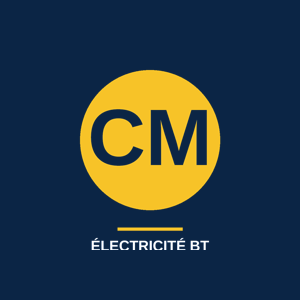

In [ ]:
from PIL import Image
import numpy as np

# Ouvrir le logo
img = Image.open("logo.png").convert("RGBA")
data = np.array(img)

# Détecter la couleur bleue du fond (le bleu roi #0B4594)
# Toute couleur proche de ce bleu devient transparente
r, g, b, a = data[:,:,0], data[:,:,1], data[:,:,2], data[:,:,3]
bleu_fond = (r < 60) & (g > 30) & (g < 90) & (b > 100) & (b < 180)

# Rendre transparent
data[:,:,3] = np.where(bleu_fond, 0, a)

# Sauvegarder
Image.fromarray(data).save("logo.png")
print("✓ Logo transparent généré")

# Aperçu sur fond bleu foncé pour vérifier
from IPython.display import Image as IPImage, display
fond = Image.new("RGB", (300, 300), (11, 37, 69))
logo = Image.open("logo.png").resize((200, 200))
fond.paste(logo, (50, 50), logo)
fond.save("apercu_logo.png")
display(IPImage("apercu_logo.png", width=200))

In [ ]:
from google.colab import files
files.download('Manuel_Expert_Energie_Cabinet_Conseils_Malins.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install qrcode[pil]

In [ ]:
from PIL import Image, ImageDraw, ImageFont

# Créer une image 500x500 avec fond transparent
img = Image.new('RGBA', (500, 500), (255, 255, 255, 0))
draw = ImageDraw.Draw(img)

# Cercle extérieur bleu foncé
draw.ellipse([50, 50, 450, 450], fill=(11, 37, 69, 255))

# Cercle intérieur orange
draw.ellipse([80, 80, 420, 420], fill=(247, 127, 0, 255))

# Texte "CCM" au centre
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 180)
except:
    font = ImageFont.load_default()

text = "CCM"
bbox = draw.textbbox((0, 0), text, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]
x = (500 - text_width) / 2
y = (500 - text_height) / 2 - 20
draw.text((x, y), text, fill=(255, 255, 255, 255), font=font)

# Ajouter une petite ligne "CONSEILS MALINS" en bas
try:
    font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)
except:
    font_small = ImageFont.load_default()

text2 = "CONSEILS MALINS"
bbox2 = draw.textbbox((0, 0), text2, font=font_small)
x2 = (500 - (bbox2[2] - bbox2[0])) / 2
draw.text((x2, 380), text2, fill=(255, 255, 255, 255), font=font_small)

img.save("logo.png")
print("✓ Logo généré : logo.png")

✓ Logo généré : logo.png


✓ Logo généré : logo.png
  Dimensions : (800, 800)


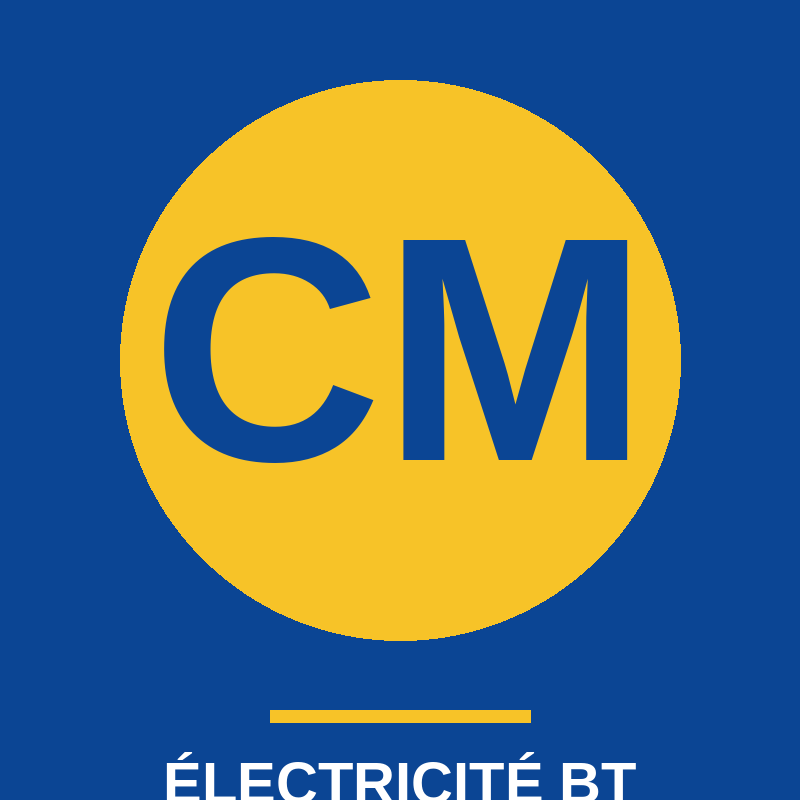

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import os

# ============================================================
# GÉNÉRATION DU LOGO CABINET CONSEILS MALINS
# ============================================================
# Couleurs
BLEU = (11, 69, 148)        # Bleu roi
JAUNE = (247, 195, 40)      # Jaune doré
BLANC = (255, 255, 255)     # Blanc pour le texte

# Dimensions
TAILLE = 800
img = Image.new('RGB', (TAILLE, TAILLE), BLEU)
draw = ImageDraw.Draw(img)

# --- Cercle jaune central ---
centre_x, centre_y = TAILLE // 2, TAILLE // 2 - 40
rayon = 280
draw.ellipse(
    [centre_x - rayon, centre_y - rayon,
     centre_x + rayon, centre_y + rayon],
    fill=JAUNE
)

# --- Texte "CM" au centre du cercle ---
# Recherche d'une police disponible dans Colab
polices_possibles = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
]

def charger_police(taille):
    for p in polices_possibles:
        if os.path.exists(p):
            return ImageFont.truetype(p, taille)
    return ImageFont.load_default()

font_cm = charger_police(320)
text_cm = "CM"

# Centrage précis du texte "CM"
bbox = draw.textbbox((0, 0), text_cm, font=font_cm)
largeur_cm = bbox[2] - bbox[0]
hauteur_cm = bbox[3] - bbox[1]
pos_x = centre_x - largeur_cm // 2 - bbox[0]
pos_y = centre_y - hauteur_cm // 2 - bbox[1] - 10

draw.text((pos_x, pos_y), text_cm, fill=BLEU, font=font_cm)

# --- Ligne jaune horizontale sous le cercle ---
ligne_y = centre_y + rayon + 70
ligne_largeur = 260
draw.rectangle(
    [centre_x - ligne_largeur // 2, ligne_y,
     centre_x + ligne_largeur // 2, ligne_y + 12],
    fill=JAUNE
)

# --- Texte "ÉLECTRICITÉ BT" ---
font_bt = charger_police(58)
text_bt = "ÉLECTRICITÉ BT"
bbox_bt = draw.textbbox((0, 0), text_bt, font=font_bt)
largeur_bt = bbox_bt[2] - bbox_bt[0]
pos_x_bt = centre_x - largeur_bt // 2 - bbox_bt[0]
pos_y_bt = ligne_y + 40

draw.text((pos_x_bt, pos_y_bt), text_bt, fill=BLANC, font=font_bt)

# --- Sauvegarde ---
img.save("logo.png")
print("✓ Logo généré : logo.png")
print(f"  Dimensions : {img.size}")

# --- Aperçu ---
from IPython.display import Image as IPImage, display
display(IPImage("logo.png", width=300))